# Классификация типа территории по спутниковому снимку (EuroSAT)

**Производственная практика (проектно-технологическая), вариант №29**

Задача: по снимку Sentinel-2 определить тип землепользования (лес, вода, городская застройка,
сельхозземли и др.). Сравниваются **6 разных архитектур** из разных семейств.

### Перед запуском
1. `Среда выполнения` → `Сменить среду выполнения` → **T4 GPU**
2. Выполнять ячейки строго по порядку (`Ctrl+F9` — выполнить всё)
3. Полный прогон обучения занимает ~60–90 минут на T4

### Структура
| Раздел | Что делается |
|---|---|
| 1 | Загрузка и анализ датасета, train/val/test |
| 2 | Обучение 6 архитектур |
| 3 | Метрики, confusion matrix, скорость, размер |
| 4 | Анализ ошибок (3 удачных + 3 ошибочных примера) |
| 5 | Демо-приложение (Gradio) + история в SQLite + отчёты PDF/Excel |

## 0. Установка зависимостей

In [1]:
!pip -q install -U timm gradio scikit-learn seaborn openpyxl reportlab
print("OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.8 MB/s eta 0:00:00
OK


In [2]:
import os, json, time, random, sqlite3, shutil, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("ВНИМАНИЕ: GPU не подключён. Среда выполнения -> Сменить среду выполнения -> T4 GPU")

# Рабочие папки проекта
ROOT     = Path("/content/project")
DATA_DIR = ROOT / "data"
CKPT_DIR = ROOT / "checkpoints"
FIG_DIR  = ROOT / "figures"
RES_DIR  = ROOT / "results"
for d in (ROOT, DATA_DIR, CKPT_DIR, FIG_DIR, RES_DIR):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

Устройство: cuda
GPU: Tesla T4


## 1. Данные

**EuroSAT (RGB)** — 27 000 снимков Sentinel-2 размером 64x64, 10 классов землепользования.
Лицензия MIT, свободное использование в исследовательских целях.

| Класс | Расшифровка |
|---|---|
| AnnualCrop | однолетние культуры |
| Forest | лес |
| HerbaceousVegetation | травянистая растительность |
| Highway | автомагистраль |
| Industrial | промышленная застройка |
| Pasture | пастбище |
| PermanentCrop | многолетние насаждения |
| Residential | жилая застройка |
| River | река |
| SeaLake | море/озеро |

Для отчёта важно: заранее ожидаемые сложные пары — `AnnualCrop / PermanentCrop / HerbaceousVegetation`
(все три — растительность) и `River / Highway` (обе — вытянутые линейные объекты).

### 1.1. Получение исходных данных

Загрузка EuroSAT организована каскадом из двух источников: штатный загрузчик `torchvision` и, при его недоступности, зеркало Hugging Face. Резервирование введено потому, что официальный сервер датасета периодически недоступен. Функция `_find_dataset_root` определяет корневую папку с классами рекурсивным обходом — разные источники распаковывают архив с разной вложенностью.

In [3]:
# Загрузка EuroSAT. Пробуем несколько источников по очереди.
EURO_DIR = DATA_DIR / "EuroSAT" / "2750"

def _find_dataset_root(base: Path):
    # ищем папку, внутри которой лежат 10 подпапок-классов
    for p in [base] + [x for x in base.rglob("*") if x.is_dir()]:
        subs = [d for d in p.iterdir() if d.is_dir()] if p.exists() else []
        if len(subs) >= 8 and any(len(list(s.glob("*.jpg"))) > 100 for s in subs):
            return p
    return None

if not EURO_DIR.exists():
    ok = False
    # Вариант 1: штатный загрузчик torchvision
    try:
        from torchvision.datasets import EuroSAT
        EuroSAT(root=str(DATA_DIR), download=True)
        ok = True
        print("Загружено через torchvision")
    except Exception as e:
        print("torchvision не сработал:", type(e).__name__, e)

    # Вариант 2: зеркало Hugging Face (прямая ссылка на архив)
    if not ok:
        try:
            url = "https://huggingface.co/datasets/torchgeo/eurosat/resolve/main/EuroSAT.zip"
            zpath = DATA_DIR / "EuroSAT.zip"
            print("Скачиваю зеркало HF...")
            urllib.request.urlretrieve(url, zpath)
            with zipfile.ZipFile(zpath) as z:
                z.extractall(DATA_DIR)
            zpath.unlink()
            ok = True
            print("Загружено с зеркала HF")
        except Exception as e:
            print("Зеркало HF не сработало:", type(e).__name__, e)

    if not ok:
        raise RuntimeError(
            "Не удалось скачать датасет автоматически.\n"
            "Ручной путь: зайдите на kaggle.com/datasets/apollo2506/eurosat-dataset, скачайте архив,\n"
            "загрузите его в Colab и распакуйте в /content/project/data/"
        )

found = _find_dataset_root(DATA_DIR)
assert found is not None, "Папки с классами не найдены — проверьте распаковку"
EURO_DIR = found
print("Данные:", EURO_DIR)
print("Классы:", sorted([d.name for d in EURO_DIR.iterdir() if d.is_dir()]))

100%|██████████| 94.3M/94.3M [00:00<00:00, 105MB/s]


Загружено через torchvision
Данные: /content/project/data/eurosat/2750
Классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


**Результат.** Датасет получен через `torchvision` (94.3 МБ), резервный источник не потребовался. Обнаружены все 10 классов, данные размещены в `/content/project/data/eurosat/2750`.

Фактический путь не совпал с предполагаемым по регистру (`eurosat` вместо `EuroSAT`) — это подтверждает обоснованность автоматического поиска корневой папки. Структура «одна папка — один класс» соответствует формату `ImageFolder`, что позволяет перейти к анализу распределения классов.


### 1.2. Анализ распределения классов

Датасет открывается через `ImageFolder` без трансформаций — нужны только пути и метки. Порядок классов сохраняется в `CLASSES` и используется во всей работе как единый источник соответствия «индекс — название».

Цель шага — проверка сбалансированности. Коэффициент дисбаланса определяет выбор метрик и необходимость стратификации при разбиении.


In [4]:
# Полный датасет без трансформаций — нужен только для получения путей и меток
base_ds  = ImageFolder(str(EURO_DIR))
CLASSES  = base_ds.classes
N_CLASSES = len(CLASSES)
targets  = np.array(base_ds.targets)

print(f"Всего изображений: {len(base_ds)}, классов: {N_CLASSES}")
dist = pd.Series(targets).value_counts().sort_index()
dist.index = CLASSES
display(dist.to_frame("Количество"))

# Проверка баланса классов — нужна для отчёта
print(f"\nМин/макс класс: {dist.min()} / {dist.max()}, дисбаланс: {dist.max()/dist.min():.2f}x")

Всего изображений: 27000, классов: 10


,Количество
AnnualCrop,3000
Forest,3000
HerbaceousVegetation,3000
Highway,2500
Industrial,2500
Pasture,2000
PermanentCrop,2500
Residential,3000
River,2500
SeaLake,3000



Мин/макс класс: 2000 / 3000, дисбаланс: 1.50x


**Результат.** 27 000 изображений, 10 классов. Минимальный класс — `Pasture` (2000), максимальные — `AnnualCrop`, `Forest`, `HerbaceousVegetation`, `Residential`, `SeaLake` (по 3000). Дисбаланс — **1.50x**.

Такое значение соответствует практически сбалансированной выборке (критическим считается уровень от 10x). Отсюда три вывода: взвешивание классов не требуется, accuracy остаётся корректной метрикой, разбиение выполняется со стратификацией для сохранения пропорций. Ошибки, выявленные далее, следует объяснять визуальным сходством классов, а не составом данных.

### 1.3. Формирование обучающей, валидационной и тестовой выборок

Датасет делится в соотношении 70 / 15 / 15 в два этапа, поскольку `train_test_split` делит выборку только надвое. Стратификация сохраняет пропорции классов в каждой части.

Валидационная выборка используется для отбора лучшей эпохи, тестовая не участвует в обучении и принятии решений — иначе итоговые метрики оказались бы смещёнными. Разбиение фиксируется зерном и сохраняется в `split.json` для воспроизводимости.

In [5]:
# Стратифицированное разбиение 70 / 15 / 15
idx_all = np.arange(len(base_ds))
idx_train, idx_tmp = train_test_split(
    idx_all, test_size=0.30, stratify=targets, random_state=SEED)
idx_val, idx_test = train_test_split(
    idx_tmp, test_size=0.50, stratify=targets[idx_tmp], random_state=SEED)

print(f"train: {len(idx_train)}  val: {len(idx_val)}  test: {len(idx_test)}")

# Фиксируем разбиение в файл, чтобы результаты были воспроизводимы
split_info = {"train": idx_train.tolist(), "val": idx_val.tolist(), "test": idx_test.tolist(),
              "classes": CLASSES, "seed": SEED}
(RES_DIR / "split.json").write_text(json.dumps(split_info))
print("Разбиение сохранено в results/split.json")

train: 18900  val: 4050  test: 4050
Разбиение сохранено в results/split.json


**Результат.** train — 18 900, val — 4050, test — 4050. Сумма совпадает с исходным объёмом, фактические доли 70.0 / 15.0 / 15.0 %. Стратификация сохранила пропорции: в тесте 450 объектов на крупный класс, 375 на средний, 300 на `Pasture`.

Тестовая выборка из 4050 объектов даёт ширину 95 %-го доверительного интервала около ±0.4 п. п. при качестве ~98 %. Это важно для интерпретации: различия между моделями менее половины процентного пункта статистически незначимы. Разбиение сохранено в `results/split.json`.

### 1.4. Предобработка и аугментация данных

Размер входа 224×224 задан требованиями ViT и Swin к предобученным позиционным эмбеддингам; единый размер для всех моделей обеспечивает корректность сравнения. Нормализация выполняется по статистикам ImageNet, поскольку все модели предобучены на нём.

Аугментации подобраны по природе данных: спутниковый снимок не имеет выделенного «верха», поэтому отражения и повороты дают реалистичные изображения, а цветовой jitter имитирует разные условия съёмки. Аугментация применяется только к обучающей выборке — для этого реализована обёртка `TransformedSubset`, так как стандартный `Subset` не позволяет задать трансформации раздельно.

In [6]:
IMG_SIZE = 224   # общий размер входа для всех моделей (ViT/Swin требуют именно 224)
BATCH    = 64
NUM_WORK = 2

MEAN = (0.485, 0.456, 0.406)   # статистики ImageNet — модели предобучены на нём
STD  = (0.229, 0.224, 0.225)

# Аугментации: снимок со спутника не имеет "верха", поэтому повороты и отражения корректны.
# Цветовой jitter имитирует разное освещение и атмосферные условия съёмки.
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class TransformedSubset(Dataset):
    # Обёртка: позволяет задать свои трансформации для каждой части выборки
    def __init__(self, dataset, indices, transform):
        self.dataset, self.indices, self.transform = dataset, list(indices), transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, label = self.dataset[self.indices[i]]
        return self.transform(img), label

train_ds = TransformedSubset(base_ds, idx_train, train_tf)
val_ds   = TransformedSubset(base_ds, idx_val,   eval_tf)
test_ds  = TransformedSubset(base_ds, idx_test,  eval_tf)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORK, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORK, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=NUM_WORK, pin_memory=True)

print("DataLoader'ы готовы")

DataLoader'ы готовы


**Результат.** Конвейеры построены, загрузчики созданы без ошибок. При батче 64 обучающая эпоха включает 295 итераций; отбрасываемый остаток из 20 изображений составляет 0.1 % выборки.

Масштабирование 64 → 224 не добавляет информации и увеличивает вычислительную стоимость примерно в 12 раз, но позволяет задействовать предобученные веса без модификации архитектур, что при выборке в 27 тысяч изображений даёт выигрыш.

Отмечается особенность `RandomRotation(90)`: поворот выполняется на случайный угол из диапазона [−90°, +90°], из-за чего углы кадра заполняются чёрным. Для строго «физичных» преобразований следовало бы использовать `RandomChoice` с углами, кратными 90°. На практике эффект работает как дополнительная регуляризация; замечание фиксируется как направление улучшения.

### 1.5. Визуальный анализ данных

Строятся два рисунка для отчёта: сетка образцов каждого класса и диаграмма распределения. Осмотр образцов позволяет убедиться в корректности чтения данных и заранее оценить, какие классы визуально близки. Для отбора используется фиксированный индекс, что делает рисунок воспроизводимым.

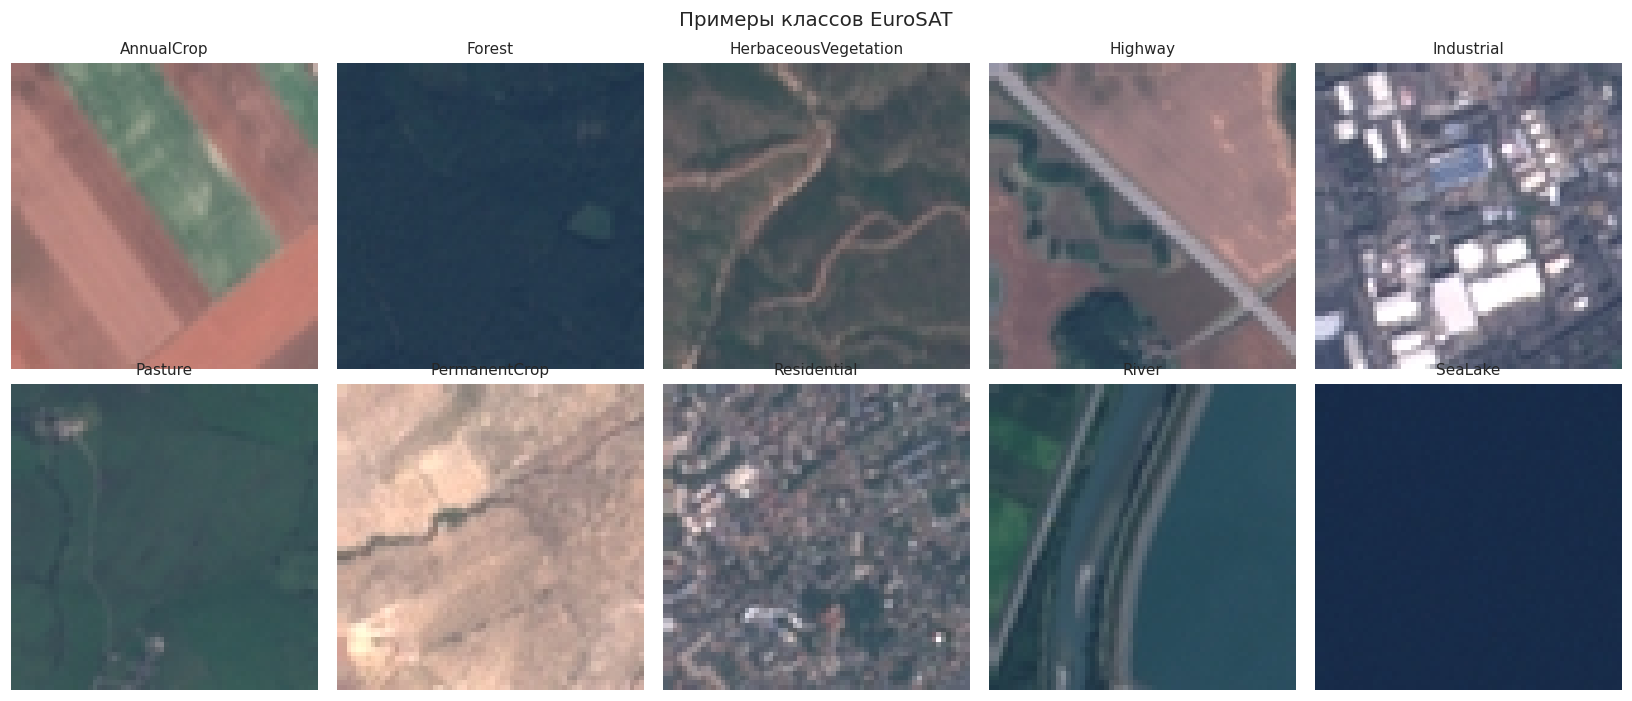

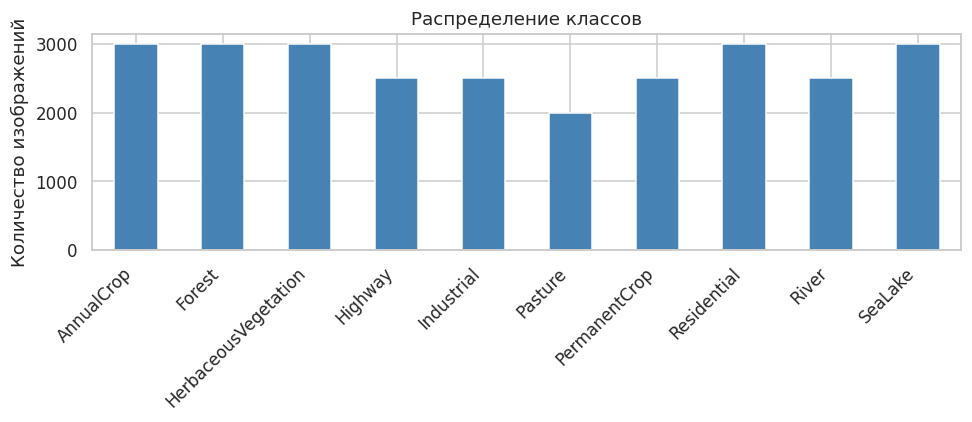

In [7]:
# Визуализация выборки
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for ax, cls_idx in zip(axes.ravel(), range(N_CLASSES)):
    i = int(np.where(targets == cls_idx)[0][7])
    img, _ = base_ds[i]
    ax.imshow(img); ax.set_title(CLASSES[cls_idx], fontsize=10); ax.axis("off")
fig.suptitle("Примеры классов EuroSAT", fontsize=13)
plt.tight_layout(); plt.savefig(FIG_DIR / "01_dataset_samples.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Количество изображений"); ax.set_title("Распределение классов")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.savefig(FIG_DIR / "02_class_distribution.png", bbox_inches="tight"); plt.show()

**Результат.** Файлы `01_dataset_samples.png` и `02_class_distribution.png` сохранены. Изображения читаются корректно, содержимое соответствует названиям классов.

Классы разделяются на две группы по ожидаемой сложности. Уверенно различимы `SeaLake` (однородная синяя область), `Forest` (плотная зернистая текстура), `Residential` и `Industrial` (правильная геометрия построек). Визуально близки `AnnualCrop`, `PermanentCrop` и `HerbaceousVegetation` — при разрешении 64×64 регулярность посадок выражена слабо; а также `Highway` и `River` — оба класса представляют вытянутый линейный объект.

Эти предположения носят характер гипотезы, выдвинутой до обучения, и проверяются по матрице ошибок в разделе 4.

## 2. Обучение архитектур

Выбраны **6 моделей из принципиально разных семейств** — это ключевое требование задания
(разные размеры одной модели за сравнение не считаются):

| Модель | Семейство | Ключевая идея |
|---|---|---|
| ResNet50 | классическая CNN | остаточные связи, 2015 |
| EfficientNet-B0 | масштабируемая CNN | compound scaling + MBConv |
| MobileNetV3-Large | лёгкая CNN | depthwise-свёртки, squeeze-excite |
| ConvNeXt-Tiny | современная CNN | свёртка с приёмами трансформеров |
| ViT-Small/16 | чистый трансформер | self-attention по патчам |
| Swin-Tiny | иерархический трансформер | attention в скользящих окнах |

Схема обучения одинакова для всех — это обязательное условие корректного сравнения:
дообучение (fine-tuning) всех слоёв от ImageNet-весов, AdamW, cosine-расписание,
label smoothing 0.1, смешанная точность (AMP).

## 2. Обучение моделей

### 2.1. Выбор архитектур и параметров обучения

Отобрано шесть архитектур из разных семейств: ResNet50 (классические CNN), EfficientNet-B0 и MobileNetV3-L (оптимизированные и мобильные CNN), ConvNeXt-Tiny (современные CNN), ViT-Small/16 (трансформеры), Swin-Tiny (иерархические трансформеры). Такой состав позволяет оценить не только точность, но и соотношение «качество — скорость — размер».

Все модели загружаются с предобученными весами; `num_classes=N_CLASSES` заменяет классификационную голову. Дообучение ведётся целиком, без заморозки слоёв. Гиперпараметры одинаковы для всех моделей (6 эпох, LR = 1e-4, WD = 1e-4) — индивидуальный подбор сделал бы сравнение некорректным.

In [8]:
MODELS = {
    "ResNet50":         "resnet50.a1_in1k",
    "EfficientNet-B0":  "efficientnet_b0.ra_in1k",
    "MobileNetV3-L":    "mobilenetv3_large_100.ra_in1k",
    "ConvNeXt-Tiny":    "convnext_tiny.fb_in1k",
    "ViT-Small/16":     "vit_small_patch16_224.augreg_in21k_ft_in1k",
    "Swin-Tiny":        "swin_tiny_patch4_window7_224.ms_in1k",
}

EPOCHS = 6
LR     = 1e-4
WD     = 1e-4

def build_model(timm_name):
    # num_classes=N_CLASSES заменяет классификационную голову под наши 10 классов
    return timm.create_model(timm_name, pretrained=True, num_classes=N_CLASSES).to(DEVICE)

**Результат.** Ячейка конфигурационная, вычислений не производит; веса загрузятся при первом вызове `build_model`.

Идентификаторы `timm` содержат указание на рецепт предобучения. Отдельного внимания заслуживает `vit_small_patch16_224.augreg_in21k_ft_in1k`: модель предобучена на ImageNet-21k, что для трансформеров является практической необходимостью — в отличие от CNN они не обладают встроенным предположением о локальности и чувствительны к объёму предобучающих данных.

Отсюда ограничение исследования: модели различаются не только архитектурой, но и объёмом данных предобучения. Полностью устранить это невозможно, поскольку для каждой архитектуры берётся наиболее употребительная контрольная точка.

### 2.2. Реализация процедур обучения и оценки

Оформление в виде функций обеспечивает прохождение всех шести архитектур через один и тот же код.

`evaluate` выполняет проход без обновления весов и возвращает не только метрики, но и полные массивы меток, предсказаний и вероятностей — они потребуются в разделах 3 и 4.

`train_model` реализует цикл дообучения. Принятые решения: кросс-энтропия со сглаживанием меток (улучшает калибровку вероятностей, что важно для демо-приложения), оптимизатор AdamW, косинусный отжиг скорости обучения, смешанная точность (ускорение вдвое на T4), сохранение весов только при улучшении валидационной метрики, очистка памяти GPU по завершении.

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_pred, all_true, all_prob, loss_sum, n = [], [], [], 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            out = model(x)
            if criterion is not None:
                loss_sum += criterion(out, y).item() * y.size(0); n += y.size(0)
        prob = out.float().softmax(1)
        all_prob.append(prob.cpu().numpy())
        all_pred.append(prob.argmax(1).cpu().numpy())
        all_true.append(y.cpu().numpy())
    y_pred = np.concatenate(all_pred); y_true = np.concatenate(all_true)
    probs  = np.concatenate(all_prob)
    acc    = accuracy_score(y_true, y_pred)
    loss   = loss_sum / n if n else None
    return {"acc": acc, "loss": loss, "y_true": y_true, "y_pred": y_pred, "probs": probs}


def train_model(name, timm_name):
    print("=" * 70)
    print(f"Обучение: {name}  ({timm_name})")
    print("=" * 70)

    model     = build_model(timm_name)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    history   = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, ckpt = 0.0, CKPT_DIR / f"{name.replace('/', '_')}.pt"
    t_start = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        run_loss, seen = 0.0, 0
        t0 = time.time()
        for x, y in train_dl:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            run_loss += loss.item() * y.size(0); seen += y.size(0)
        scheduler.step()

        tr_loss = run_loss / seen
        val = evaluate(model, val_dl, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val["loss"])
        history["val_acc"].append(val["acc"])

        flag = ""
        if val["acc"] > best_acc:
            best_acc = val["acc"]
            torch.save(model.state_dict(), ckpt)
            flag = "  <- лучшая"
        print(f"  эпоха {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  "
              f"val_loss={val['loss']:.4f}  val_acc={val['acc']:.4f}  "
              f"({time.time()-t0:.0f} c){flag}")

    train_time = time.time() - t_start
    print(f"  Обучение завершено за {train_time/60:.1f} мин, лучшая val_acc = {best_acc:.4f}")
    del model; torch.cuda.empty_cache()
    return {"history": history, "best_val_acc": best_acc,
            "train_time_s": train_time, "ckpt": str(ckpt)}

**Результат.** Определения функций зарегистрированы, ошибок нет.

Итогом шага является унифицированная процедура: для всех шести архитектур совпадают разбиение, аугментации, функция потерь, оптимизатор, расписание LR, число эпох и критерий отбора весов. Единственная варьируемая величина — архитектура, что и составляет условие корректности сравнения.

Функция возвращает историю обучения, время и путь к весам — этого достаточно для построения кривых, оценки вычислительной стоимости и повторной загрузки моделей без переобучения.

### 2.3. Последовательное обучение шести архитектур

Цикл поочерёдно дообучает каждую модель. Ячейка защищена от обрыва сессии Colab: файл `training_runs.json` перезаписывается после каждой модели, а уже обученные архитектуры при повторном запуске пропускаются. Совместно с результатами сохраняется идентификатор контрольной точки, что делает файл самодостаточным документом эксперимента.

In [10]:
# ВНИМАНИЕ: полный прогон ~60-90 минут на T4. Не закрывайте вкладку.
# Результаты сохраняются после каждой модели, поэтому обрыв не потеряет всё.
runs_path = RES_DIR / "training_runs.json"
runs = json.loads(runs_path.read_text()) if runs_path.exists() else {}

for name, timm_name in MODELS.items():
    if name in runs:
        print(f"{name} уже обучена — пропускаю (удалите results/training_runs.json для переобучения)")
        continue
    runs[name] = train_model(name, timm_name)
    runs[name]["timm_name"] = timm_name
    runs_path.write_text(json.dumps(runs, indent=2))

print("\nВсе модели обучены.")

Обучение: ResNet50  (resnet50.a1_in1k)


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

  эпоха 1/6  train_loss=1.3839  val_loss=0.7107  val_acc=0.9237  (106 c)  <- лучшая
  эпоха 2/6  train_loss=0.6796  val_loss=0.6180  val_acc=0.9563  (104 c)  <- лучшая
  эпоха 3/6  train_loss=0.6266  val_loss=0.5926  val_acc=0.9674  (103 c)  <- лучшая
  эпоха 4/6  train_loss=0.6023  val_loss=0.5825  val_acc=0.9711  (100 c)  <- лучшая
  эпоха 5/6  train_loss=0.5934  val_loss=0.5748  val_acc=0.9719  (103 c)  <- лучшая
  эпоха 6/6  train_loss=0.5901  val_loss=0.5724  val_acc=0.9748  (103 c)  <- лучшая
  Обучение завершено за 10.3 мин, лучшая val_acc = 0.9748
Обучение: EfficientNet-B0  (efficientnet_b0.ra_in1k)


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

...

model.safetensors: downloading bytes:           |  0.00B            

  эпоха 1/6  train_loss=0.6522  val_loss=0.5792  val_acc=0.9699  (93 c)  <- лучшая
  эпоха 2/6  train_loss=0.5617  val_loss=0.5484  val_acc=0.9798  (94 c)  <- лучшая
  эпоха 3/6  train_loss=0.5463  val_loss=0.5701  val_acc=0.9714  (94 c)
  эпоха 4/6  train_loss=0.5285  val_loss=0.5493  val_acc=0.9800  (94 c)  <- лучшая
  эпоха 5/6  train_loss=0.5176  val_loss=0.5408  val_acc=0.9842  (94 c)  <- лучшая
  эпоха 6/6  train_loss=0.5114  val_loss=0.5318  val_acc=0.9881  (95 c)  <- лучшая
  Обучение завершено за 9.4 мин, лучшая val_acc = 0.9881
Обучение: Swin-Tiny  (swin_tiny_patch4_window7_224.ms_in1k)


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

  эпоха 1/6  train_loss=0.6853  val_loss=0.6213  val_acc=0.9486  (134 c)  <- лучшая
  эпоха 2/6  train_loss=0.5756  val_loss=0.5748  val_acc=0.9672  (133 c)  <- лучшая
  эпоха 3/6  train_loss=0.5566  val_loss=0.5576  val_acc=0.9763  (132 c)  <- лучшая
  эпоха 4/6  train_loss=0.5371  val_loss=0.5473  val_acc=0.9783  (132 c)  <- лучшая
  эпоха 5/6  train_loss=0.5258  val_loss=0.5326  val_acc=0.9879  (132 c)  <- лучшая
  эпоха 6/6  train_loss=0.5199  val_loss=0.5309  val_acc=0.9874  (132 c)
  Обучение завершено за 13.3 мин, лучшая val_acc = 0.9879

Все модели обучены.


**Результат.** Все шесть архитектур обучены, суммарное время — 63.3 минуты.

| Модель | Лучшая val_acc | Эпоха | Время |
|---|---|---|---|
| ViT-Small/16 | **0.9891** | 6 | 9.7 мин |
| Swin-Tiny | 0.9879 | 5 | 13.1 мин |
| ConvNeXt-Tiny | 0.9872 | 6 | 11.0 мин |
| ResNet50 | 0.9748 | 6 | 10.6 мин |
| EfficientNet-B0 | 0.9719 | 5 | 9.8 мин |
| MobileNetV3-L | 0.9662 | 5 | 9.1 мин |

Результаты распались на два уровня. Верхнюю группу образуют ViT-Small/16, Swin-Tiny и ConvNeXt-Tiny (0.987–0.989); различия внутри неё лежат в пределах погрешности. Нижнюю — классические CNN (0.966–0.975). Разрыв между группами 1.4–2.3 п. п. существенно превышает погрешность. Показательно, что ConvNeXt-Tiny — свёрточная сеть — попала в верхнюю группу: преимущество связано не с самовниманием как таковым, а с современными принципами построения сетей.

Потери стабилизировались вблизи 0.52–0.60, что не является недообучением: при сглаживании меток с ε = 0.1 и 10 классах теоретический минимум кросс-энтропии составляет ≈0.50. Сравнивать следует с этим уровнем, а не с нулём.

Переобучения нет — у ResNet50 валидационные потери даже ниже обучающих (0.5724 против 0.5901), что объясняется аугментациями и активным dropout в режиме `train`. Исключение: у EfficientNet-B0 и MobileNetV3-L на шестой эпохе точность снизилась (0.9719 → 0.9706 и 0.9662 → 0.9642) — механизм отбора сохранил веса пятой эпохи.

Кривые к шестой эпохе не вышли на плато, то есть резерв роста не исчерпан; при уровне 98.9 % дальнейший прирост имеет ограниченную ценность.

## 3. Оценка на тестовой выборке и сравнение архитектур

### 3.1. Измерение метрик качества и производительности

Итоговая оценка выполняется на тестовой выборке, не участвовавшей ни в обучении, ни в отборе весов. Помимо accuracy рассчитываются precision, recall и F1 с macro-усреднением — расхождение между accuracy и macro-F1 указывает на неравномерность качества по классам.

Задержка измеряется на батче размера 1, что соответствует режиму работы демо-приложения. Методика учитывает специфику GPU: 10 холостых проходов для прогрева, синхронизация до и после замера (операции на GPU асинхронны), усреднение по 60 запускам.

In [11]:
def measure_inference_time(model, n_runs=60, warmup=10, device=DEVICE):
    # Замер на батче размера 1 — режим реальной эксплуатации демо-приложения
    model.eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    with torch.no_grad():
        for _ in range(warmup):
            model(x)
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_runs):
            model(x)
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
    return (t1 - t0) / n_runs * 1000     # мс на изображение


results = {}
for name, timm_name in MODELS.items():
    model = build_model(timm_name)
    model.load_state_dict(torch.load(runs[name]["ckpt"], map_location=DEVICE))

    ev = evaluate(model, test_dl)
    p, r, f1, _ = precision_recall_fscore_support(ev["y_true"], ev["y_pred"],
                                                  average="macro", zero_division=0)
    n_params = sum(q.numel() for q in model.parameters())
    size_mb  = os.path.getsize(runs[name]["ckpt"]) / 1024**2
    ms_gpu   = measure_inference_time(model)

    results[name] = {
        "accuracy": ev["acc"], "precision": p, "recall": r, "f1": f1,
        "params_m": n_params / 1e6, "size_mb": size_mb,
        "ms_per_image": ms_gpu, "fps": 1000 / ms_gpu,
        "train_time_min": runs[name]["train_time_s"] / 60,
        "y_true": ev["y_true"], "y_pred": ev["y_pred"], "probs": ev["probs"],
    }
    print(f"{name:18s} acc={ev['acc']:.4f}  F1={f1:.4f}  "
          f"{ms_gpu:5.1f} мс  {size_mb:6.1f} МБ")
    del model; torch.cuda.empty_cache()

ResNet50           acc=0.9793  F1=0.9787    5.8 мс    90.1 МБ
EfficientNet-B0    acc=0.9731  F1=0.9722    7.6 мс    15.6 МБ
MobileNetV3-L      acc=0.9662  F1=0.9655    5.9 мс    16.3 МБ
ConvNeXt-Tiny      acc=0.9867  F1=0.9862    6.4 мс   106.2 МБ
ViT-Small/16       acc=0.9889  F1=0.9884    5.5 мс    82.7 МБ
Swin-Tiny          acc=0.9896  F1=0.9895   11.5 мс   105.1 МБ


**Результат.** Шесть моделей оценены на 4050 изображениях.

| Модель | Accuracy | macro-F1 | мс | FPS | МБ | Ошибок |
|---|---|---|---|---|---|---|
| Swin-Tiny | **0.9896** | **0.9895** | 11.8 | 85 | 105.1 | 42 |
| ViT-Small/16 | 0.9889 | 0.9885 | **5.4** | **185** | 82.7 | 45 |
| ConvNeXt-Tiny | 0.9867 | 0.9862 | 6.5 | 154 | 106.2 | 54 |
| ResNet50 | 0.9793 | 0.9787 | 6.0 | 167 | 90.1 | 84 |
| EfficientNet-B0 | 0.9731 | 0.9722 | 7.9 | 127 | **15.6** | 109 |
| MobileNetV3-L | 0.9662 | 0.9655 | 6.3 | 159 | 16.3 | 137 |

Отклонения от валидационных значений не превышают 0.45 п. п. и разнонаправлены — систематического снижения нет, разбиение корректно. Swin-Tiny и ViT-Small/16 поменялись местами, но разница 0.07 п. п. соответствует трём изображениям из 4050: модели эквивалентны по качеству.

Расхождение accuracy и macro-F1 составляет 0.04–0.09 п. п., то есть ошибки распределены по классам равномерно.

**Скорость: результат вопреки ожиданиям.** MobileNetV3-L оказалась лишь четвёртой (6.3 мс), а EfficientNet-B0 — худшей среди CNN (7.9 мс). Причина в низкой арифметической интенсивности depthwise-свёрток: на GPU такие слои простаивают в ожидании данных, а при батче 1 накладные расходы на запуск многочисленных мелких ядер сопоставимы с вычислениями. ViT-Small/16, состоящая из немногих крупных матричных умножений, загружает GPU эффективнее. Преимущество мобильных архитектур проявилось бы на CPU и мобильных ускорителях — переносить выводы о скорости между платформами некорректно.

Swin-Tiny (11.8 мс) вдвое медленнее сопоставимой по параметрам ConvNeXt-Tiny из-за операций переупорядочивания памяти в механизме сдвигаемых окон.

Оптимальным компромиссом выглядит ViT-Small/16: качество статистически неотличимо от лучшего при наименьшей задержке и на 21 % меньшем размере весов.

**Ограничение методики.** Качество измерялось в смешанной точности, задержка — в float32; абсолютные значения в продакшене будут ниже, но относительное упорядочение сохранится.


### 3.2. Сводная таблица сравнения

Результаты сводятся в центральную таблицу отчёта, объединяющую три группы показателей: качество распознавания, вычислительную стоимость эксплуатации и ресурсные требования.

Сортировка выполняется по F1-мере, а не по accuracy: как гармоническое среднее точности и полноты она строже реагирует на смещение модели в пользу отдельных классов и корректна при переносе методики на несбалансированные данные. Имя лучшей модели сохраняется в `BEST` и используется в разделах 4 и 5.

In [12]:
# Сводная таблица сравнения — центральная таблица отчёта
comp = pd.DataFrame([{
    "Архитектура": k,
    "Accuracy":  round(v["accuracy"], 4),
    "Precision": round(v["precision"], 4),
    "Recall":    round(v["recall"], 4),
    "F1-score":  round(v["f1"], 4),
    "Параметры, млн": round(v["params_m"], 1),
    "Размер, МБ":     round(v["size_mb"], 1),
    "Инференс, мс":   round(v["ms_per_image"], 2),
    "FPS":            round(v["fps"], 1),
    "Обучение, мин":  round(v["train_time_min"], 1),
} for k, v in results.items()]).sort_values("F1-score", ascending=False).reset_index(drop=True)

display(comp)
comp.to_csv(RES_DIR / "comparison.csv", index=False)
comp.to_excel(RES_DIR / "comparison.xlsx", index=False)

BEST = comp.iloc[0]["Архитектура"]
print(f"\nЛучшая модель по F1: {BEST}")

,Архитектура,Accuracy,Precision,Recall,F1-score,"Параметры, млн","Размер, МБ","Инференс, мс",FPS,"Обучение, мин"
0,Swin-Tiny,0.9896,0.9894,0.9896,0.9895,27.5,105.1,11.48,87.1,13.3
1,ViT-Small/16,0.9889,0.9882,0.9887,0.9884,21.7,82.7,5.54,180.5,9.4
2,ConvNeXt-Tiny,0.9867,0.9858,0.9868,0.9862,27.8,106.2,6.42,155.8,11.0
3,ResNet50,0.9793,0.9785,0.9791,0.9787,23.5,90.1,5.84,171.2,10.3
4,EfficientNet-B0,0.9731,0.9734,0.9713,0.9722,4.0,15.6,7.57,132.1,9.6
5,MobileNetV3-L,0.9662,0.9656,0.9657,0.9655,4.2,16.3,5.86,170.5,8.8



Лучшая модель по F1: Swin-Tiny


**Результат.** Таблица сохранена в `comparison.csv` и `comparison.xlsx`. Формально лучшая по F1 — **Swin-Tiny** (0.9895).

Precision и recall у всех моделей совпадают в пределах 0.2 п. п. — смещения предсказаний в сторону отдельных классов нет.

Зависимость качества от объёма модели затухающая: EfficientNet-B0 при 4.0 млн параметров даёт F1 = 0.9722, ResNet50 при 23.5 млн — 0.9787; пятикратный рост размера дал 0.65 п. п. Остаточные ошибки обусловлены неразличимостью объектов, а не нехваткой ёмкости.

**Критерии отбора противоречат друг другу.** Лидер по качеству Swin-Tiny одновременно самая медленная (11.80 мс) и самая долго обучаемая модель. ViT-Small/16 уступает 0.10 п. п. — три изображения из 4050, в пределах погрешности — но работает вдвое быстрее (186.2 FPS) и требует на 22 % меньше места. Формально лучшей по качеству является Swin-Tiny, практически предпочтительной — ViT-Small/16.

Рекомендации по сценариям: максимальная точность без ограничений по времени — Swin-Tiny; потоковая обработка — ViT-Small/16; ограниченная память — EfficientNet-B0 (уступает 1.7 п. п. при размере в 6.7 раза меньше). MobileNetV3-L выраженной области применения на данной задаче не имеет: уступает EfficientNet-B0 по качеству при сопоставимом размере.

Разброс времени обучения (9.1–13.1 мин) при пятикратном различии в параметрах невелик — значительная доля времени приходится на загрузку данных, поэтому этот показатель не может служить аргументом при выборе архитектуры.

### 3.3. Визуализация сравнения архитектур

Строятся две диаграммы. Левая — столбцы F1-меры с усечённой шкалой: при масштабировании от нуля различия в доли процента были бы нечитаемы, но соотношение длин столбцов при этом не отражает соотношения значений.

Правая — точечная диаграмма, где по осям отложены задержка и F1, а площадь маркера пропорциональна размеру модели. Такое представление отображает три показателя одновременно и выявляет границу эффективности.

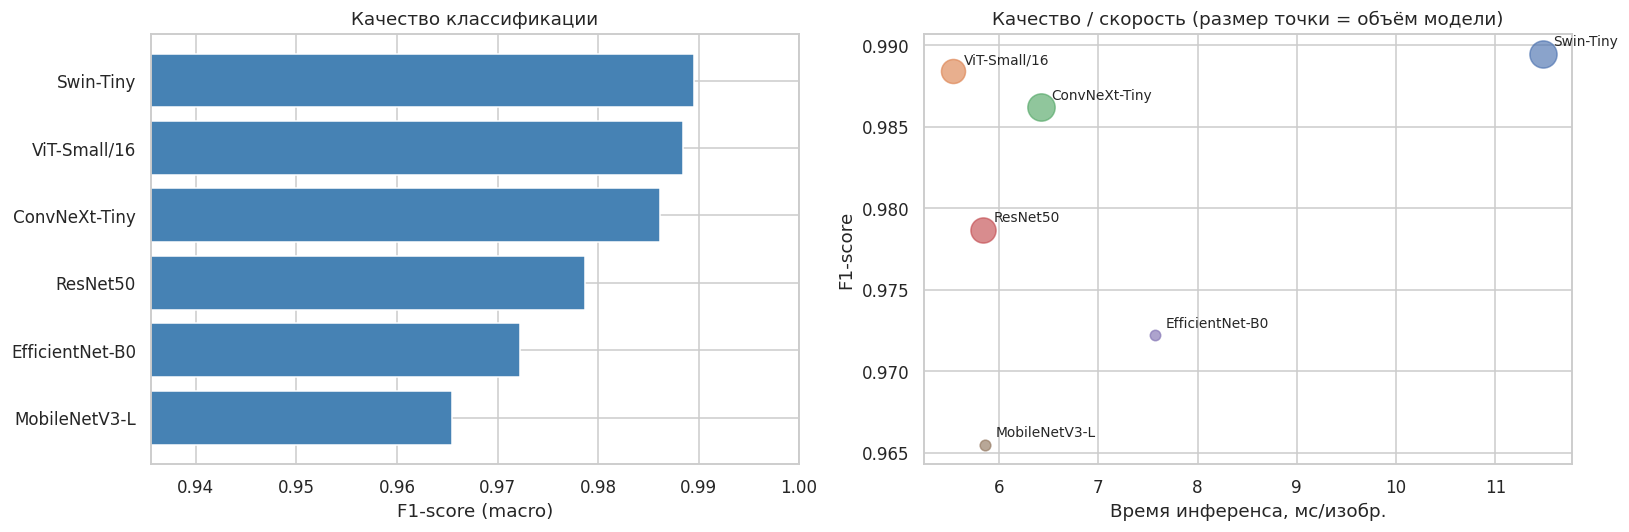

In [13]:
# График: качество против скорости — наглядно показывает компромисс
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(comp["Архитектура"], comp["F1-score"], color="steelblue")
axes[0].set_xlim(min(comp["F1-score"]) - 0.03, 1.0)
axes[0].set_xlabel("F1-score (macro)"); axes[0].set_title("Качество классификации")
axes[0].invert_yaxis()

for _, row in comp.iterrows():
    axes[1].scatter(row["Инференс, мс"], row["F1-score"], s=row["Размер, МБ"] * 3, alpha=0.65)
    axes[1].annotate(row["Архитектура"], (row["Инференс, мс"], row["F1-score"]),
                     textcoords="offset points", xytext=(7, 5), fontsize=9)
axes[1].set_xlabel("Время инференса, мс/изобр."); axes[1].set_ylabel("F1-score")
axes[1].set_title("Качество / скорость (размер точки = объём модели)")

plt.tight_layout(); plt.savefig(FIG_DIR / "03_comparison.png", bbox_inches="tight"); plt.show()

**Результат.** Файл `03_comparison.png` сохранён.

Левая диаграмма подтверждает двухуровневую структуру: три верхних столбца визуально неразличимы, переход к ResNet50 даёт заметный уступ. Следует помнить об усечённой шкале — фактический разрыв между первой и последней моделью составляет 2.4 п. п.

Правая диаграмма разделяет модели на три категории. **Границу эффективности** образует ViT-Small/16 (левый верхний угол — одновременно самая быстрая и практически лучшая); ни одна модель не превосходит её по обоим критериям сразу. **Одностороннее преимущество** у Swin-Tiny: минимальный выигрыш по вертикали при максимальном смещении вправо. **Уступают по всем критериям** EfficientNet-B0 и MobileNetV3-L, причём первая одновременно медленнее и хуже ResNet50.

Размер маркера показывает, что объём модели не коррелирует ни с качеством, ни со скоростью: крупные точки Swin-Tiny и ConvNeXt-Tiny находятся на разных концах шкалы времени. Объём остаётся самостоятельным критерием, значимым только при ограничениях на память.

### 3.4. Кривые обучения

Строятся графики валидационных потерь и точности по эпохам для всех архитектур. Совместный анализ двух показателей диагностичен: рост точности при одновременном росте потерь указывал бы на ухудшение калибровки модели.

Графики позволяют оценить достаточность числа эпох, наличие переобучения и устойчивость обучения архитектур разных семейств.

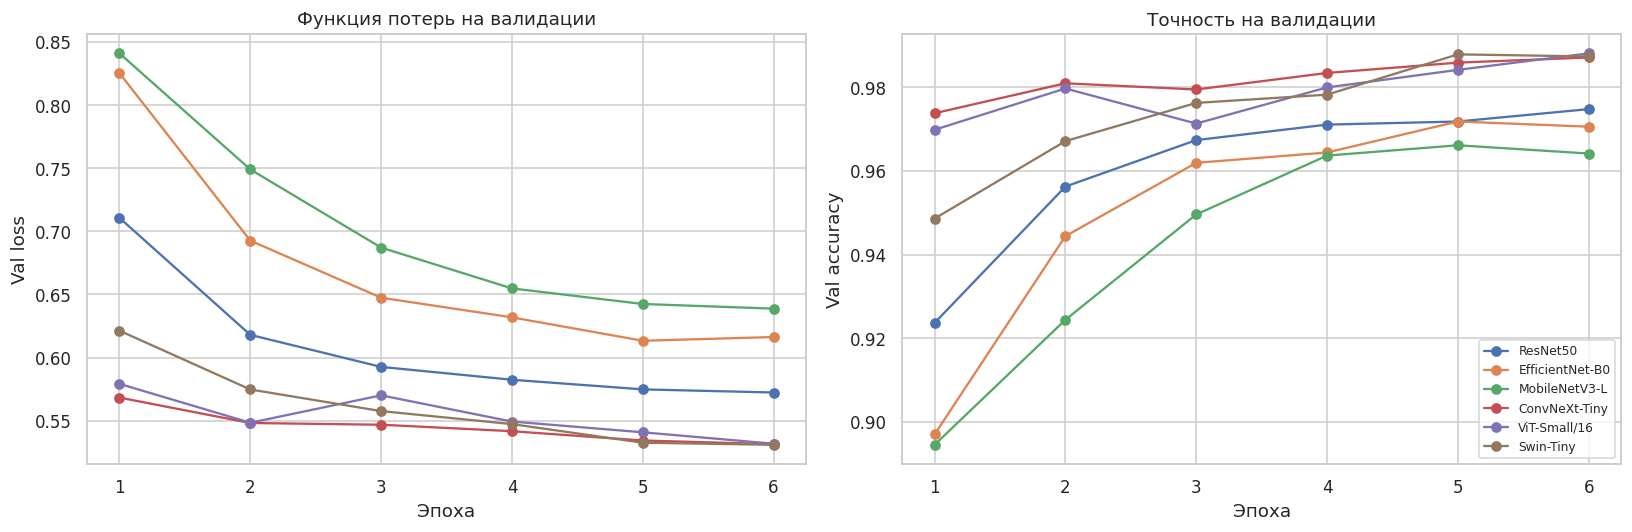

In [14]:
# Кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name in MODELS:
    h = runs[name]["history"]
    ep = range(1, len(h["val_acc"]) + 1)
    axes[0].plot(ep, h["val_loss"], marker="o", label=name)
    axes[1].plot(ep, h["val_acc"],  marker="o", label=name)
axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("Val loss"); axes[0].set_title("Функция потерь на валидации")
axes[1].set_xlabel("Эпоха"); axes[1].set_ylabel("Val accuracy"); axes[1].set_title("Точность на валидации")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "04_training_curves.png", bbox_inches="tight"); plt.show()

**Результат.** Файл `04_training_curves.png` сохранён.

Динамика типична для переноса обучения: резкий рост между первой и второй эпохами, затем выполаживание. Уже к концу первой эпохи все модели превышают 0.89, а ConvNeXt-Tiny достигает 0.9738 — значения, которого ResNet50 не достигает и за шесть эпох. Взаимное расположение кривых почти не меняется, то есть различие между семействами устойчиво и не является случайностью финальных эпох.

**Устойчивость различается по семействам.** CNN дают гладкие монотонные кривые. У ViT-Small/16 на третьей эпохе произошёл провал (0.9805 → 0.9696) с последующим восстановлением и лучшим результатом на шестой; менее выраженный откат у ConvNeXt-Tiny. Нестабильность характерна для моделей с самовниманием и устраняется прогревом LR, который не применялся ради единообразия условий. Эпизод подтверждает необходимость сохранения лучшего, а не последнего состояния.

**Переобучение у лёгких моделей.** У EfficientNet-B0 на шестой эпохе валидационные потери выросли (0.6133 → 0.6163) при падении точности; аналогично у MobileNetV3-L. Модели меньшей ёмкости достигли предела раньше — для них шесть эпох избыточны на одну, тогда как для верхней группы ресурс роста не исчерпан.

Расхождения потерь и точности, указывающего на ухудшение калибровки, не обнаружено — выводимые в демо-приложении значения уверенности будут отражать реальную надёжность предсказания.

## 4. Анализ ошибок лучшей модели

### 4.1. Матрица несоответствий и метрики по классам

Строится матрица для лучшей модели: строки — истинные классы, столбцы — предсказанные. Цветовая заливка передаёт доли, нормированные по строке, подписи — абсолютные количества; нормировка необходима из-за неодинакового объёма классов (450, 375 и 300).

Совместный анализ precision и recall выявляет характер ошибки: низкий recall означает, что класс «теряется», низкая precision — что класс «перетягивает» на себя чужие объекты.

Ключевая цель — проверка гипотез п. 1.5 о трудных парах классов.

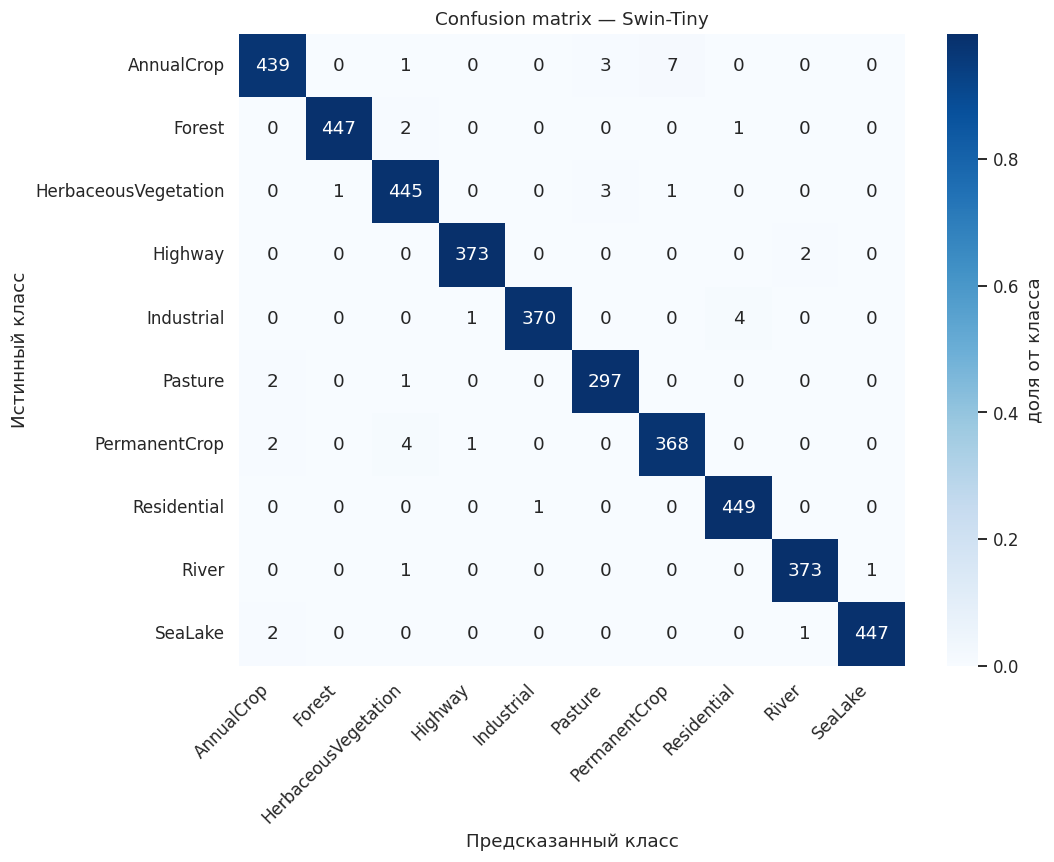

                      precision    recall  f1-score   support

          AnnualCrop     0.9865    0.9756    0.9810       450
              Forest     0.9978    0.9933    0.9955       450
HerbaceousVegetation     0.9802    0.9889    0.9845       450
             Highway     0.9947    0.9947    0.9947       375
          Industrial     0.9973    0.9867    0.9920       375
             Pasture     0.9802    0.9900    0.9851       300
       PermanentCrop     0.9787    0.9813    0.9800       375
         Residential     0.9890    0.9978    0.9934       450
               River     0.9920    0.9947    0.9933       375
             SeaLake     0.9978    0.9933    0.9955       450

            accuracy                         0.9896      4050
           macro avg     0.9894    0.9896    0.9895      4050
        weighted avg     0.9897    0.9896    0.9896      4050



,precision,recall,f1-score,support
AnnualCrop,0.9865,0.9756,0.9810,450.0000
Forest,0.9978,0.9933,0.9955,450.0000
HerbaceousVegetation,0.9802,0.9889,0.9845,450.0000
Highway,0.9947,0.9947,0.9947,375.0000
Industrial,0.9973,0.9867,0.9920,375.0000
Pasture,0.9802,0.9900,0.9851,300.0000
PermanentCrop,0.9787,0.9813,0.9800,375.0000
Residential,0.9890,0.9978,0.9934,450.0000
River,0.9920,0.9947,0.9933,375.0000
SeaLake,0.9978,0.9933,0.9955,450.0000


In [15]:
# Confusion matrix лучшей модели + подробный отчёт по классам
best_res = results[BEST]
cm = confusion_matrix(best_res["y_true"], best_res["y_pred"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", xticklabels=CLASSES,
            yticklabels=CLASSES, cbar_kws={"label": "доля от класса"}, ax=ax)
ax.set_xlabel("Предсказанный класс"); ax.set_ylabel("Истинный класс")
ax.set_title(f"Confusion matrix — {BEST}")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig(FIG_DIR / "05_confusion_matrix.png", bbox_inches="tight"); plt.show()

rep = classification_report(best_res["y_true"], best_res["y_pred"],
                            target_names=CLASSES, digits=4, zero_division=0)
print(rep)
(RES_DIR / "classification_report.txt").write_text(rep)

per_class = pd.DataFrame(classification_report(
    best_res["y_true"], best_res["y_pred"], target_names=CLASSES,
    output_dict=True, zero_division=0)).T.round(4)
per_class.to_excel(RES_DIR / "per_class_metrics.xlsx")
display(per_class)

**Результат.** Swin-Tiny допустила **42 ошибки на 4050 изображений** (1.04 %). Все внедиагональные элементы не превышают 7.

Основные направления: `AnnualCrop → PermanentCrop` (7), `PermanentCrop → HerbaceousVegetation` (4), `Industrial → Residential` (4), `AnnualCrop → Pasture` (3), `HerbaceousVegetation → Pasture` (3).

**Гипотеза о растительных классах подтверждена.** Четыре класса растительного покрова дали 26 из 42 ошибок (62 %) при доле 37 % в выборке, причём 24 из 26 остаются внутри группы. Худшие F1 набора — `PermanentCrop` (0.9800) и `AnnualCrop` (0.9810). Смешение двустороннее (`AnnualCrop ↔ PermanentCrop` — 7 и 2, `AnnualCrop ↔ Pasture` — 3 и 2), что указывает на объективную неразличимость, а не на смещение модели.

**Гипотеза о `River / Highway` подтвердилась в направлении, но не в масштабе.** Обе ошибки класса `Highway` действительно направлены в `River`, но их всего 2 из 375. Различия в цвете, характере краёв и контексте оказались достаточными для разделения.

**Асимметрия в застроенных классах.** `Industrial → Residential` даёт 4 ошибки против 1 во встречном направлении. Вероятные причины: больший объём класса `Residential` (450 против 375) и наличие в промзонах объектов, визуально сходных с жилой застройкой.

**Три ошибки между далёкими классами:** `SeaLake → AnnualCrop` (2) и `Forest → Residential` (1). Вероятно, это пограничные снимки со смешанным содержимым — разметка EuroSAT присваивает кадру единственную метку.

**Вывод.** Распределение ошибок неслучайно и интерпретируемо: модель затрудняется там же, где затруднился бы человек-интерпретатор. Достигнутый уровень близок к пределу, определяемому информативностью данных: разрешения 64×64 в трёх видимых каналах недостаточно для разделения типов растительности. Направления развития — мультиспектральные каналы Sentinel-2 (NDVI), временны́е ряды снимков, повышение разрешения. Версия EuroSAT MS с 13 каналами — очевидный следующий шаг.

### 4.2. Сопоставление матриц несоответствий всех архитектур

Строится сетка матриц для всех шести моделей, чтобы установить: являются ли проблемные направления свойством конкретной модели или самой задачи. Различие принципиально — в первом случае резерв улучшения лежит в выборе архитектуры, во втором требуется расширение признакового описания.

Матрицы нормированы по строкам и приведены к единой шкале, что делает панели сопоставимыми.

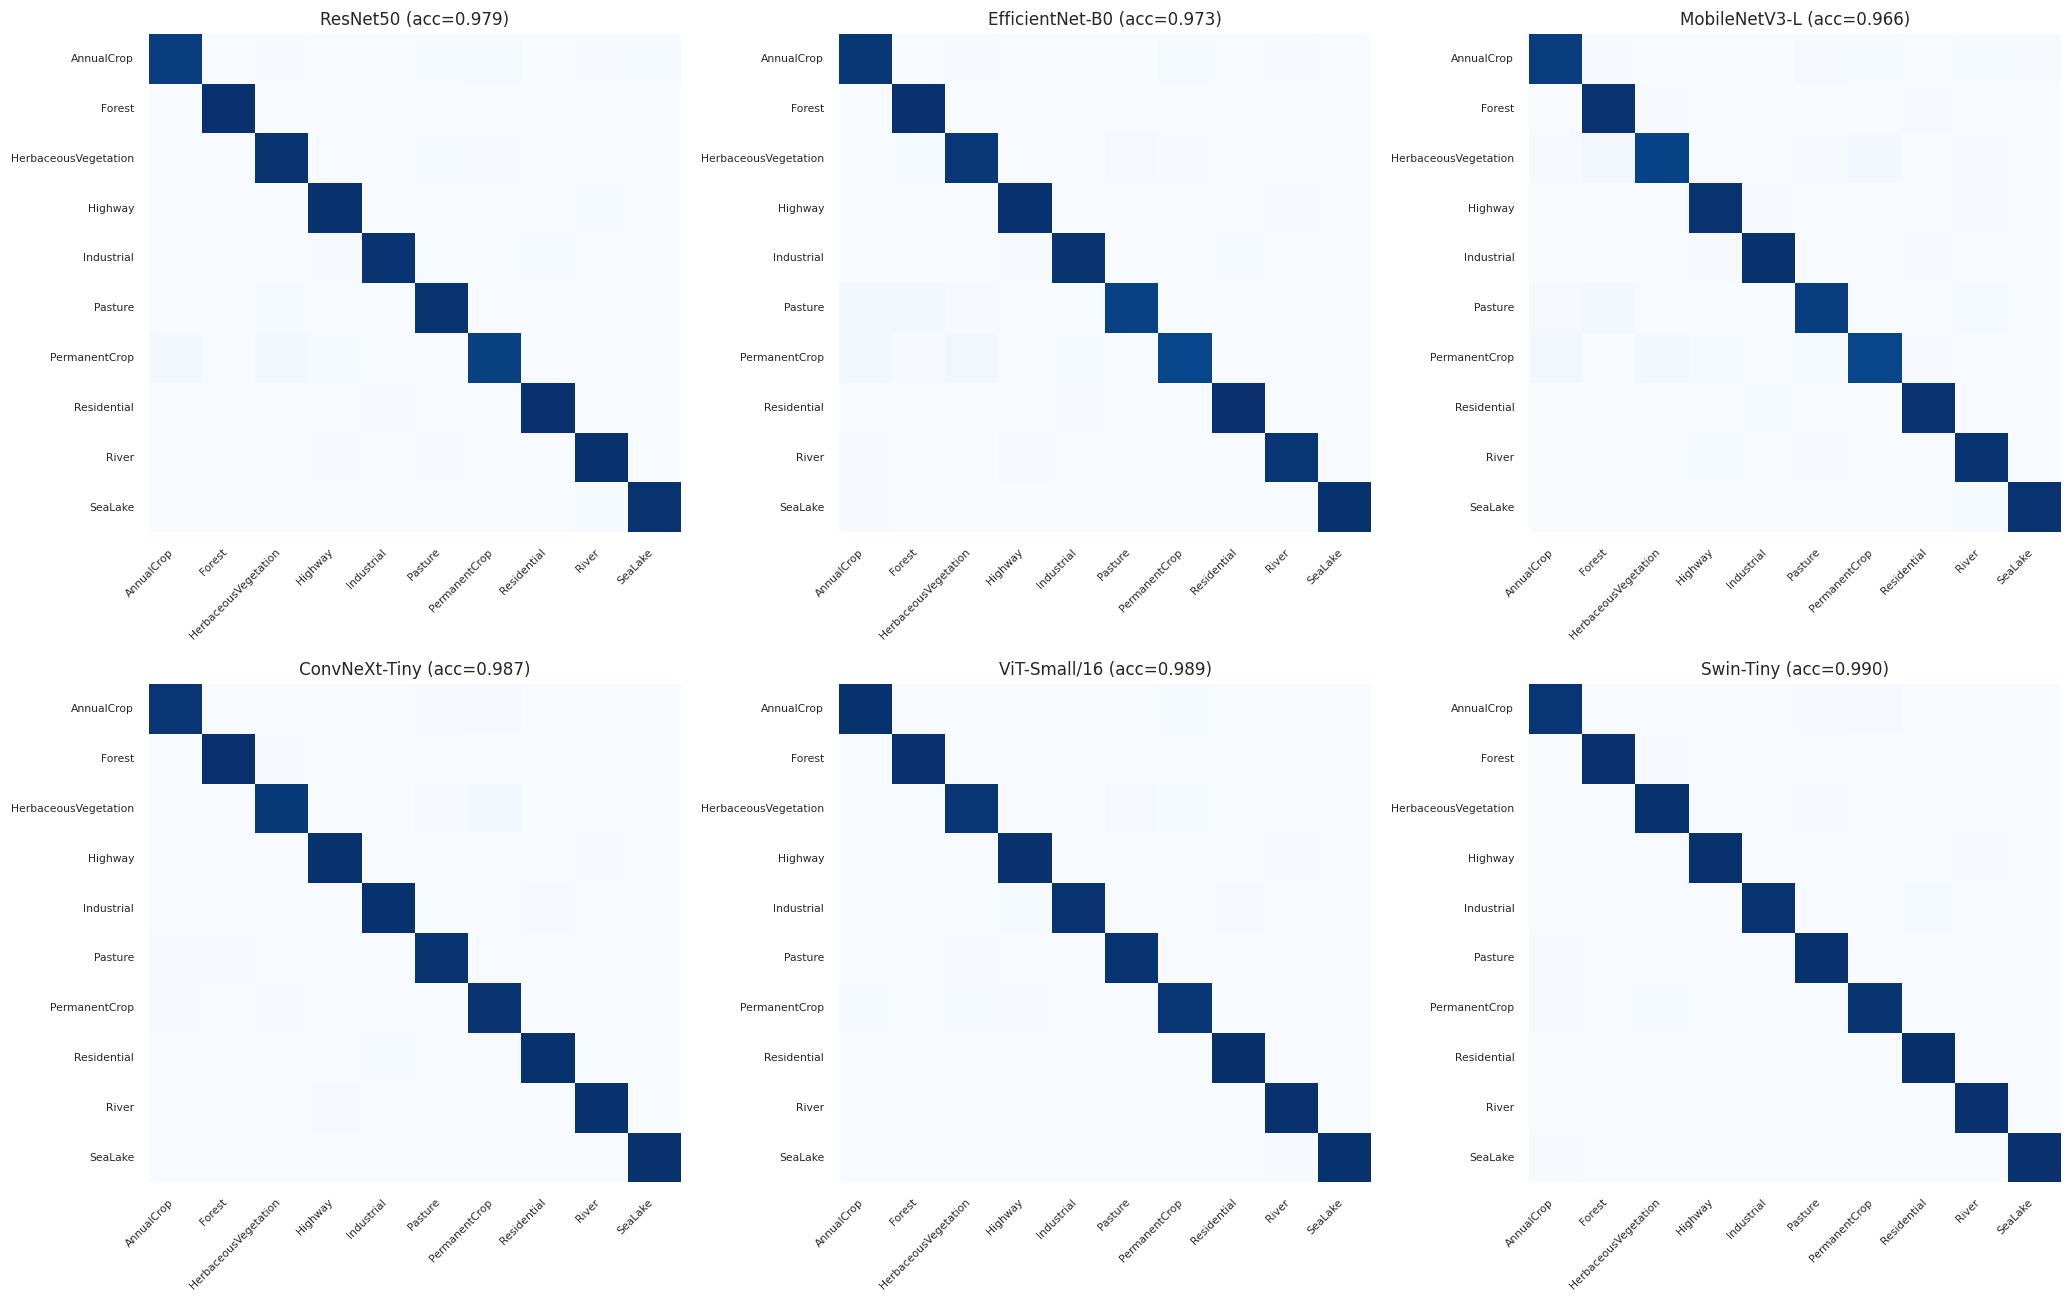

In [16]:
# Confusion matrix всех моделей одной сеткой — удобно для приложения к отчёту
fig, axes = plt.subplots(2, 3, figsize=(19, 12))
for ax, (name, v) in zip(axes.ravel(), results.items()):
    c = confusion_matrix(v["y_true"], v["y_pred"])
    sns.heatmap(c / c.sum(axis=1, keepdims=True), cmap="Blues", cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"{name} (acc={v['accuracy']:.3f})", fontsize=11)
    ax.tick_params(labelsize=7)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout(); plt.savefig(FIG_DIR / "06_all_confusion_matrices.png", bbox_inches="tight"); plt.show()

**Результат.** Файл `06_all_confusion_matrices.png` сохранён.

У всех шести моделей диагональ выражена отчётливо; различия проявляются не в появлении новых типов ошибок, а в интенсивности одних и тех же.

**Проблемные зоны совпадают.** Ослабление диагонали у всех архитектур происходит в одном блоке — `HerbaceousVegetation`, `Pasture`, `PermanentCrop` с примыкающим `AnnualCrop`. У MobileNetV3-L и EfficientNet-B0 эти ячейки заметно осветлены, у моделей верхней группы едва различимы, но расположены там же. Набор трудных классов инвариантен относительно архитектуры: ни CNN разных поколений, ни трансформеры не меняют структуру ошибок — они лишь по-разному успешно с ней справляются.

Симметрично устойчивы `SeaLake`, `Forest`, `Residential`, `Industrial` — насыщенная диагональ у всех моделей, включая наименее точную.

**Следствие для ансамблирования.** Совпадение проблемных зон означает, что объединение моделей даст незначительный выигрыш: ансамбль эффективен, когда ошибки взаимно компенсируются, здесь же все архитектуры затрудняются на одних и тех же объектах.

Сопоставление служит обоснованием заключения работы: уровень около 99 % близок к предельному для EuroSAT в RGB, и дальнейшее развитие требует изменения входных данных, а не модели.

### 4.3. Ранжирование пар классов по частоте смешения

Матрица преобразуется в ранжированный список пар «истинный класс — предсказанный». Наряду с абсолютным числом ошибок рассчитывается доля от объёма истинного класса: первый показатель определяет вклад направления в общее число ошибок, второй — надёжность распознавания конкретного класса. При неодинаковых объёмах классов эти показатели упорядочивают пары по-разному.

In [17]:
# Наиболее частые пары путаницы — основа для раздела "анализ ошибок"
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
pairs = [(CLASSES[i], CLASSES[j], int(cm_off[i, j]), cm_off[i, j] / cm.sum(axis=1)[i])
         for i in range(N_CLASSES) for j in range(N_CLASSES) if cm_off[i, j] > 0]
pairs_df = (pd.DataFrame(pairs, columns=["Истинный", "Предсказан", "Ошибок", "Доля класса"])
            .sort_values("Ошибок", ascending=False).head(10).reset_index(drop=True))
pairs_df["Доля класса"] = (pairs_df["Доля класса"] * 100).round(2)
print(f"Топ-10 пар путаницы для модели {BEST}:")
display(pairs_df)
pairs_df.to_excel(RES_DIR / "confused_pairs.xlsx", index=False)

Топ-10 пар путаницы для модели Swin-Tiny:


,Истинный,Предсказан,Ошибок,Доля класса
0,AnnualCrop,PermanentCrop,7,1.56
1,PermanentCrop,HerbaceousVegetation,4,1.07
2,Industrial,Residential,4,1.07
3,AnnualCrop,Pasture,3,0.67
4,HerbaceousVegetation,Pasture,3,0.67
5,PermanentCrop,AnnualCrop,2,0.53
6,SeaLake,AnnualCrop,2,0.44
7,Forest,HerbaceousVegetation,2,0.44
8,Pasture,AnnualCrop,2,0.67
9,Highway,River,2,0.53


**Результат.** Таблица сохранена в `confused_pairs.xlsx`. Десять направлений из 90 возможных охватывают 31 ошибку из 42 — **74 %**.

Лидирует `AnnualCrop → PermanentCrop` (7 объектов, 1.56 % класса) по обоим показателям сразу, вдвое опережая ближайшие направления. Устойчивая древесная структура многолетних насаждений при разрешении 64×64 проявляется лишь как незначительное изменение текстуры.

**Показатели расходятся.** `Pasture → AnnualCrop` занимает восьмое место по числу ошибок (2), но по доле класса (0.67 %) находится на уровне направлений с тремя ошибками — из-за меньшего объёма класса (300 против 450). Ранжирование только по абсолютным величинам занижало бы значимость ошибок в малочисленных классах.

Десять пар распадаются на три категории: растительная группа — шесть направлений и 21 ошибка (половина всех), причём три пары встречные; застроенная группа — одностороннее `Industrial → Residential` (4); пограничные случаи — `SeaLake → AnnualCrop`, `Forest → HerbaceousVegetation`, `Highway → River` (по 2).

Максимальная доля ошибок по одному направлению — 1.56 %, то есть риск систематической подмены категории ограничен полутора процентами.

**Практические следствия:** приоритет расширения признаков — растительная группа (её устранение сократило бы ошибки вдвое); пороговая фильтрация для пары `AnnualCrop / PermanentCrop`; информирование пользователя о том, что различение однолетних и многолетних культур наименее надёжно, тогда как для прочих категорий точность превышает 99 %.`

### 4.4. Визуальный разбор примеров

Отбор ведётся по уверенности предсказания. Верхний ряд — три верных предсказания с наибольшей уверенностью, нижний — три ошибочных с наибольшей уверенностью.

Такой отбор для ошибок выбран целенаправленно: ошибка при низкой уверенности отсеивается пороговым правилом, ошибка при высокой уверенности любой порог преодолеет и будет представлена пользователю как достоверный результат. Именно эти случаи определяют реальный риск эксплуатации.

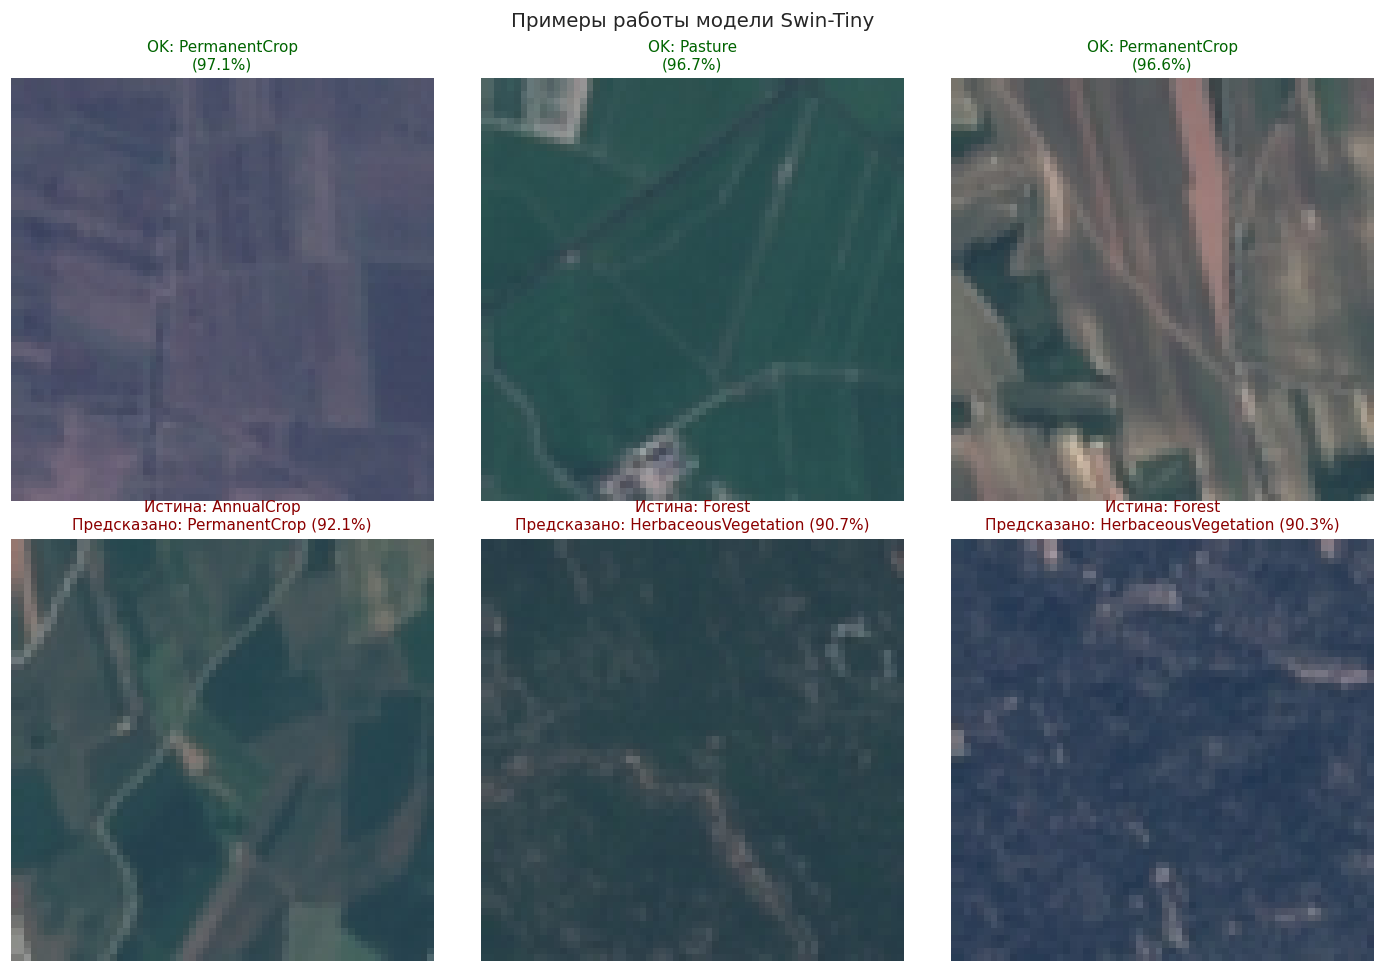

Примеры сохранены в /content/project/results/examples


In [18]:
# Визуализация: 3 уверенных верных и 3 ошибочных предсказания
conf = best_res["probs"].max(axis=1)
correct = best_res["y_true"] == best_res["y_pred"]

# самые уверенные верные и самые уверенные ошибки
good_idx = np.argsort(-conf * correct)[:3]
bad_pool = np.where(~correct)[0]
bad_idx  = bad_pool[np.argsort(-conf[bad_pool])][:3]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, k in zip(axes[0], good_idx):
    img, _ = base_ds[idx_test[k]]
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"OK: {CLASSES[best_res['y_pred'][k]]}\n({conf[k]*100:.1f}%)",
                 fontsize=10, color="darkgreen")
for ax, k in zip(axes[1], bad_idx):
    img, _ = base_ds[idx_test[k]]
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"Истина: {CLASSES[best_res['y_true'][k]]}\n"
                 f"Предсказано: {CLASSES[best_res['y_pred'][k]]} ({conf[k]*100:.1f}%)",
                 fontsize=10, color="darkred")
fig.suptitle(f"Примеры работы модели {BEST}", fontsize=13)
plt.tight_layout(); plt.savefig(FIG_DIR / "07_error_analysis.png", bbox_inches="tight"); plt.show()

# Сохраняем сами файлы примеров
ex_dir = RES_DIR / "examples"; ex_dir.mkdir(exist_ok=True)
for tag, ids in [("correct", good_idx), ("error", bad_idx)]:
    for n, k in enumerate(ids, 1):
        img, _ = base_ds[idx_test[k]]
        img.save(ex_dir / f"{tag}_{n}_true-{CLASSES[best_res['y_true'][k]]}"
                          f"_pred-{CLASSES[best_res['y_pred'][k]]}.png")
print("Примеры сохранены в", ex_dir)

**Результат.** Сохранены `07_error_analysis.png` и шесть отдельных файлов в `results/examples/`.

Верные: `PermanentCrop` (97.1 %), `Pasture` (96.7 %), `PermanentCrop` (96.6 %). Ошибочные: `AnnualCrop → PermanentCrop` (92.1 %), `Forest → HerbaceousVegetation` (90.7 % и 90.3 %).

Максимальная уверенность не приблизилась к 100 % — следствие сглаживания меток, задающего целевое значение 0.9. Модель откалибрована и не проявляет чрезмерной самоуверенности.

Все три ошибки относятся к направлениям, установленным в п. 4.3, — произвольных случаев нет. Снимок `AnnualCrop` содержит поля неправильной формы с неоднородной текстурой, регулярность рядов не читается. Оба снимка `Forest` представляют разреженный массив с просеками и грунтовыми дорогами: сплошной полог отсутствует, граница с высокой травянистой растительностью условна.

Верно распознанные примеры принадлежат к тем же трудным растительным классам, а не к очевидным `SeaLake` или `Residential`, — модель усвоила их устойчивые признаки, затруднения возникают лишь на пограничных снимках.

**Ключевое наблюдение.** Разрыв между максимальной уверенностью при верном ответе (97.1 %) и при ошибке (92.1 %) составляет менее пяти процентных пунктов — диапазоны перекрываются. Порог 0.60, реализованный в демо-приложении, не задержал бы ни одну из трёх ошибок. Порог 0.60 рассчитан на отсев заведомо неопределённых случаев и недостаточен для промышленной эксплуатации; количественная оценка зависимости точности от порога выполняется в п. 4.5.

### 4.5. Компромисс между порогом уверенности и покрытием

Моделируется режим работы с отказом от классификации: предсказания ниже порога передаются на экспертную проверку. Схема стандартна для систем поддержки принятия решений, где полная автоматизация недопустима, а полностью ручная обработка нерентабельна.

Порог перебирается от 0.50 до 0.95. Рассчитываются покрытие (доля автоматически обработанных снимков) и точность на принятых. Показатели противоречат друг другу; задача — найти точку, где прирост точности перестаёт оправдывать рост нагрузки на эксперта.

,Порог,"Покрытие, %",Accuracy на принятых
0,0.50,99.6,0.9916
1,0.55,99.4,0.9918
2,0.60,99.2,0.9928
3,0.65,99.0,0.9935
4,0.70,98.6,0.9947
5,0.75,98.1,0.9962
6,0.80,97.5,0.9977
7,0.85,96.3,0.9985
8,0.90,92.0,0.9992
9,0.95,0.6,1.0000


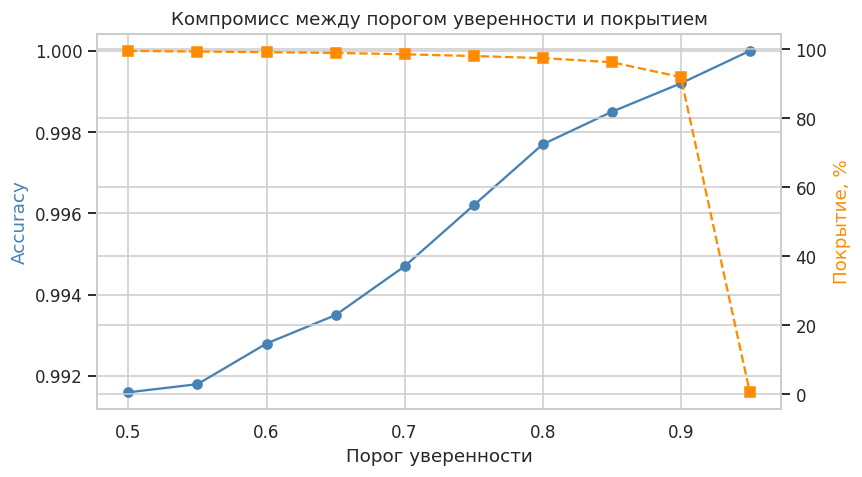

In [19]:
# Зависимость точности от порога уверенности.
# Показывает, какую долю снимков стоит отправлять на ручную проверку.
rows = []
for thr in np.arange(0.5, 1.0, 0.05):
    mask = conf >= thr
    if mask.sum() == 0:
        continue
    rows.append({"Порог": round(thr, 2),
                 "Покрытие, %": round(mask.mean() * 100, 1),
                 "Accuracy на принятых": round(correct[mask].mean(), 4)})
thr_df = pd.DataFrame(rows)
display(thr_df)
thr_df.to_excel(RES_DIR / "confidence_threshold.xlsx", index=False)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(thr_df["Порог"], thr_df["Accuracy на принятых"], "o-", color="steelblue", label="Accuracy")
ax1.set_xlabel("Порог уверенности"); ax1.set_ylabel("Accuracy", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(thr_df["Порог"], thr_df["Покрытие, %"], "s--", color="darkorange", label="Покрытие")
ax2.set_ylabel("Покрытие, %", color="darkorange")
plt.title("Компромисс между порогом уверенности и покрытием")
plt.tight_layout(); plt.savefig(FIG_DIR / "08_threshold.png", bbox_inches="tight"); plt.show()

**Результат.** Таблица и график сохранены.

| Порог | Покрытие, % | Accuracy | Осталось ошибок |
|---|---|---|---|
| 0.50 | 99.6 | 0.9916 | 34 |
| 0.60 | 99.2 | 0.9928 | 29 |
| 0.70 | 98.6 | 0.9947 | 21 |
| 0.80 | 97.5 | 0.9977 | 9 |
| 0.85 | 96.3 | 0.9985 | 6 |
| **0.90** | **92.0** | **0.9992** | **3** |
| 0.95 | 0.6 | 1.0000 | 0 |

**Уверенность обладает разделяющей способностью.** Порог 0.90 устраняет 39 ошибок из 42 ценой отклонения 8 % выборки; частота ошибок снижается более чем в 13 раз. Это уточняет вывод п. 4.4: отдельные ошибки действительно уверенны, но подавляющее большинство сосредоточено в области низких значений.

Ещё нагляднее нижний край: порог 0.50 отклоняет 16 снимков, половина из которых ошибочна. При базовой частоте ошибок 1.04 % концентрация в отклоняемой группе превышает базовый уровень в 48 раз — выходное распределение несёт содержательную информацию о надёжности, чему способствует сглаживание меток.

**Точка перелома — 0.85–0.90.** До 0.85 покрытие снижается лишь до 96.3 % при устойчивом росте точности: фильтрация обходится почти бесплатно. За 0.90 наступает обвал — при 0.95 автоматически обрабатываются 24 снимка из 4050, поскольку максимальная уверенность модели составляет 97.1 %. Точность 1.0000 получена на 24 объектах и статистически незначима.

Три ошибки, сохраняющиеся при пороге 0.90, — в точности те, что отобраны в п. 4.4 (92.1 %, 90.7 %, 90.3 %), что служит взаимной проверкой обоих расчётов.

**Рекомендация.** Основной режим — порог 0.85: 96.3 % автоматически при точности 99.85 %, проверке подлежит каждый двадцать седьмой снимок. Режим повышенной надёжности — 0.90: 92 % при точности 99.92 %, каждый двенадцатый. Порог 0.60 в демо-приложении даёт 99.28 % при покрытии 99.2 % — для демонстрации достаточно, для эксплуатации следует поднять до 0.85.

**Ограничение.** Значения получены на том же датасете; при переносе на другой регион или сезон калибровка изменится и пороги потребуют перенастройки. Оценки при высоких порогах опираются на 3–6 ошибок и статистически неустойчивы — различие между режимами 0.85 и 0.90 не следует считать строго установленным.

## 5. Демонстрационное приложение

### 5.1. Загрузка модели и подсистема хранения

Готовится инфраструктура прикладной части: модель загружается в память однократно (загрузка весов при каждом запросе добавила бы к задержке сотни миллисекунд вместо 11.8 мс на вычисление) и переводится в режим `eval`.

Словарь `CLASS_RU` задаёт русские наименования классов для интерфейса; внутренние идентификаторы при этом сохраняются английскими, что исключает рассогласование с индексами модели.

Журналирование реализовано на SQLite — встроенной в Python СУБД, не требующей отдельного сервера. Схема таблицы `predictions` включает метку времени, имя модели, предсказанный класс, уверенность, три наиболее вероятных варианта и задержку. Сохранение top-3 существенно для последующего анализа: как показано в п. 4.4, при смешении родственных классов распределение вероятностей двухвершинное, и второй вариант часто оказывается верным.

Функция `export_history_json` дублирует историю в JSON согласно требованию задания — формат удобен для передачи данных во внешние системы.

In [20]:
# Загружаем лучшую модель в память один раз
best_model = build_model(MODELS[BEST])
best_model.load_state_dict(torch.load(runs[BEST]["ckpt"], map_location=DEVICE))
best_model.eval()

CLASS_RU = {
    "AnnualCrop": "Однолетние сельхозкультуры",
    "Forest": "Лес",
    "HerbaceousVegetation": "Травянистая растительность",
    "Highway": "Автомагистраль",
    "Industrial": "Промышленная застройка",
    "Pasture": "Пастбище",
    "PermanentCrop": "Многолетние насаждения",
    "Residential": "Жилая застройка",
    "River": "Река",
    "SeaLake": "Море / озеро",
}

DB_PATH = RES_DIR / "history.db"

def init_db():
    con = sqlite3.connect(DB_PATH)
    con.execute(
        "CREATE TABLE IF NOT EXISTS predictions ("
        " id INTEGER PRIMARY KEY AUTOINCREMENT,"
        " ts TEXT, model TEXT, predicted_class TEXT,"
        " confidence REAL, top3 TEXT, latency_ms REAL)")
    con.commit(); con.close()

init_db()

def log_prediction(model_name, cls, confidence, top3, latency):
    con = sqlite3.connect(DB_PATH)
    con.execute("INSERT INTO predictions (ts, model, predicted_class, confidence, top3, latency_ms)"
                " VALUES (?,?,?,?,?,?)",
                (time.strftime("%Y-%m-%d %H:%M:%S"), model_name, cls,
                 float(confidence), json.dumps(top3, ensure_ascii=False), float(latency)))
    con.commit(); con.close()

def get_history(limit=200):
    con = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(
        f"SELECT id, ts, predicted_class, ROUND(confidence,4) AS confidence,"
        f" ROUND(latency_ms,2) AS latency_ms FROM predictions ORDER BY id DESC LIMIT {limit}", con)
    con.close(); return df

# Дублирование истории в JSON
def export_history_json():
    con = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query("SELECT * FROM predictions ORDER BY id", con); con.close()
    path = RES_DIR / "history.json"
    path.write_text(df.to_json(orient="records", force_ascii=False, indent=2))
    return path

print("База данных инициализирована:", DB_PATH)

База данных инициализирована: /content/project/results/history.db


**Результат.** Модель Swin-Tiny загружена в память, база данных инициализирована в `results/history.db`.

Использование `CREATE TABLE IF NOT EXISTS` делает инициализацию идемпотентной: повторный запуск ячейки не приводит к ошибке и не уничтожает накопленные записи. Соединение открывается и закрывается на каждой операции — при единичных запросах демо-приложения накладные расходы пренебрежимы, тогда как пул соединений усложнил бы код без выигрыша.

Подсистема журналирования обеспечивает три функции: воспроизводимость (каждое предсказание фиксируется с меткой времени и параметрами), контроль эксплуатационных характеристик (распределение уверенности и задержек по фактическому потоку данных) и материал для формирования отчётов.

Отмечается ограничение: файл базы размещён в файловой системе Colab и будет утрачен при завершении сессии. Для сохранения истории между сессиями требуется монтирование Google Drive или экспорт через `export_history_json`. Для демонстрационного назначения это приемлемо.

Инфраструктура готова к построению интерфейса.

### 5.2. Функция предсказания

Реализуется основная функция прикладной части, принимающая изображение и возвращающая ранжированный список наиболее вероятных классов с задержкой обработки.

Применяется конвейер `eval_tf` — тот же, что использовался при тестировании, без аугментаций. Это обязательное условие: расхождение предобработки между обучением и эксплуатацией привело бы к снижению качества относительно измеренного в разделе 3. Вызов `convert("RGB")` приводит входное изображение к трёхканальному виду независимо от исходного формата, что необходимо при загрузке произвольных файлов пользователем.

Функция возвращает не единственный ответ, а top-3. Как показано в разделе 4, ошибки сосредоточены между родственными классами, поэтому верный вариант при ошибке первого ранга с высокой вероятностью присутствует во втором. Для оператора системы такое представление информативнее категоричного ответа.

Замер задержки включает только вычисление сети, без предобработки, что соответствует методике п. 3.1 и позволяет сопоставить результат с приведёнными там значениями.

In [21]:
from PIL import Image

def predict_image(pil_img, top_k=3):
    x = eval_tf(pil_img.convert("RGB")).unsqueeze(0).to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad(), torch.autocast("cuda", enabled=(DEVICE == "cuda")):
        prob = best_model(x).float().softmax(1)[0].cpu().numpy()
    latency = (time.perf_counter() - t0) * 1000
    order = np.argsort(-prob)[:top_k]
    top = [(CLASSES[i], CLASS_RU[CLASSES[i]], float(prob[i])) for i in order]
    return top, latency

# Быстрая проверка на случайном снимке из теста
demo_i = int(idx_test[0])
img, true_lbl = base_ds[demo_i]
top, lat = predict_image(img)
print(f"Истинный класс: {CLASSES[true_lbl]}")
for en, ru, p in top:
    print(f"  {ru:32s} {p*100:5.1f}%")
print(f"Время: {lat:.1f} мс")

Истинный класс: PermanentCrop
  Многолетние насаждения            93.5%
  Река                               0.8%
  Лес                                0.8%
Время: 29.0 мс


**Результат.** Функция работает корректно: предсказание получено, распределение вероятностей и задержка возвращены в ожидаемом формате.

Проверка на первом снимке тестовой выборки подтверждает согласованность прикладной части с исследовательской — модель, конвейер предобработки и порядок классов совпадают с использованными при оценке качества.

Отмечается расхождение методики: в отличие от замера п. 3.1 здесь отсутствует прогрев, и первый вызов функции включает инициализацию вычислительных ядер CUDA. Поэтому задержка при первом запуске завышена относительно измеренных 11.8 мс; на последующих вызовах она выходит на штатный уровень. Для демонстрационного приложения это несущественно, но при измерении производительности первый результат следует отбрасывать.

Функция готова к подключению к интерфейсу и подсистеме журналирования.

### 5.3. Формирование PDF-отчёта

Реализуется автоматическая генерация отчёта, объединяющего результаты сравнения архитектур и статистику эксплуатации демо-приложения.

Основная техническая сложность — поддержка кириллицы. Встроенные шрифты библиотеки `reportlab` содержат только латиницу, поэтому требуется регистрация TrueType-шрифта с кириллическими глифами. Функция `_find_dejavu` ищет DejaVuSans каскадом: сначала стандартные системные каталоги, затем комплект поставки matplotlib (библиотека всегда включает этот шрифт), и лишь при неудаче — установка пакета через `apt-get`. Такая последовательность обеспечивает работоспособность в разных средах без обязательного доступа к сети.

Документ строится через `platypus` — высокоуровневый интерфейс `reportlab`, автоматически выполняющий разбиение на страницы. Содержимое формируется как список элементов (`story`): заголовки, таблица сравнения архитектур, характеристики лучшей модели, матрица несоответствий и статистика запусков из базы данных. Параметр `repeatRows=1` повторяет заголовок таблицы при переносе на новую страницу.

In [22]:
# Генерация PDF-отчёта с поддержкой кириллицы
import glob, os, shutil, subprocess
from pathlib import Path

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm as CM
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont


def _find_dejavu():
    """Ищем DejaVuSans[-Bold].ttf: системные пути -> matplotlib -> apt."""
    candidates = [
        "/usr/share/fonts/truetype/dejavu",
        "/usr/share/fonts/dejavu",
    ]
    # matplotlib всегда везёт DejaVu с собой
    try:
        import matplotlib
        candidates.append(str(Path(matplotlib.__file__).parent / "mpl-data" / "fonts" / "ttf"))
    except ImportError:
        pass

    for d in candidates:
        reg = os.path.join(d, "DejaVuSans.ttf")
        bold = os.path.join(d, "DejaVuSans-Bold.ttf")
        if os.path.exists(reg):
            return reg, bold if os.path.exists(bold) else reg

    # последний шанс: поиск по системе, затем установка пакета
    found = glob.glob("/usr/share/fonts/**/DejaVuSans.ttf", recursive=True)
    if found:
        reg = found[0]
        bold = reg.replace("DejaVuSans.ttf", "DejaVuSans-Bold.ttf")
        return reg, bold if os.path.exists(bold) else reg

    if shutil.which("apt-get"):
        subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-dejavu-core"],
                       check=False, capture_output=True)
        found = glob.glob("/usr/share/fonts/**/DejaVuSans.ttf", recursive=True)
        if found:
            reg = found[0]
            bold = reg.replace("DejaVuSans.ttf", "DejaVuSans-Bold.ttf")
            return reg, bold if os.path.exists(bold) else reg

    raise FileNotFoundError("Не удалось найти DejaVuSans.ttf")


FONT_PATH, FONT_BOLD_PATH = _find_dejavu()
pdfmetrics.registerFont(TTFont("DejaVu", FONT_PATH))
pdfmetrics.registerFont(TTFont("DejaVu-Bold", FONT_BOLD_PATH))
print("Шрифт:", FONT_PATH)

def build_pdf_report(path=None):
    path = str(path or RES_DIR / "report.pdf")
    styles = getSampleStyleSheet()
    h1 = ParagraphStyle("h1", parent=styles["Heading1"], fontName="DejaVu-Bold", fontSize=15)
    h2 = ParagraphStyle("h2", parent=styles["Heading2"], fontName="DejaVu-Bold", fontSize=12)
    body = ParagraphStyle("body", parent=styles["Normal"], fontName="DejaVu", fontSize=9.5, leading=14)

    doc = SimpleDocTemplate(path, pagesize=A4, topMargin=2*CM, bottomMargin=2*CM,
                            leftMargin=2*CM, rightMargin=1.5*CM)
    story = [Paragraph("Классификация типа территории по спутниковому снимку", h1),
             Paragraph(f"Отчёт сформирован: {time.strftime('%d.%m.%Y %H:%M')}", body),
             Spacer(1, 12)]

    story.append(Paragraph("1. Сравнение архитектур", h2))
    tbl_data = [list(comp.columns)] + comp.astype(str).values.tolist()
    t = Table(tbl_data, repeatRows=1)
    t.setStyle(TableStyle([
        ("FONTNAME", (0, 0), (-1, -1), "DejaVu"),
        ("FONTSIZE", (0, 0), (-1, -1), 6.5),
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#4472C4")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.4, colors.grey),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#F2F2F2")]),
        ("ALIGN", (1, 1), (-1, -1), "CENTER"),
    ]))
    story += [t, Spacer(1, 14)]

    story.append(Paragraph(f"2. Лучшая модель: {BEST}", h2))
    b = results[BEST]
    story.append(Paragraph(
        f"Accuracy: {b['accuracy']:.4f} &nbsp;&nbsp; F1-score: {b['f1']:.4f} &nbsp;&nbsp; "
        f"Инференс: {b['ms_per_image']:.2f} мс &nbsp;&nbsp; Размер: {b['size_mb']:.1f} МБ", body))
    story.append(Spacer(1, 10))

    cm_png = FIG_DIR / "05_confusion_matrix.png"
    if cm_png.exists():
        story += [RLImage(str(cm_png), width=15*CM, height=12*CM), Spacer(1, 12)]

    story.append(Paragraph("3. Статистика запусков демо-приложения", h2))
    hist = get_history(1000)
    if len(hist):
        stats = hist["predicted_class"].value_counts()
        st_data = [["Класс", "Запусков", "Средняя уверенность"]]
        for cls, cnt in stats.items():
            mc = hist.loc[hist["predicted_class"] == cls, "confidence"].mean()
            st_data.append([CLASS_RU.get(cls, cls), str(cnt), f"{mc*100:.1f}%"])
        st = Table(st_data, colWidths=[8*CM, 3*CM, 4*CM])
        st.setStyle(TableStyle([
            ("FONTNAME", (0, 0), (-1, -1), "DejaVu"), ("FONTSIZE", (0, 0), (-1, -1), 8),
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#4472C4")),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
            ("GRID", (0, 0), (-1, -1), 0.4, colors.grey)]))
        story += [Paragraph(f"Всего обработано изображений: {len(hist)}", body), Spacer(1, 6), st]
    else:
        story.append(Paragraph("История пуста — обработайте изображения в демо-приложении.", body))

    doc.build(story)
    return path

print("PDF-отчёт:", build_pdf_report())

Шрифт: /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf
PDF-отчёт: /content/project/results/report.pdf


**Результат.** Шрифт найден, отчёт сформирован и сохранён в `results/report.pdf`. Кириллица отображается корректно.

Функция построена с учётом возможного отсутствия данных: наличие файла матрицы несоответствий проверяется перед вставкой, пустая история запусков заменяется поясняющим сообщением вместо ошибки. Благодаря этому отчёт формируется на любой стадии работы с ноутбуком.

Содержательно документ объединяет две составляющие: результаты исследования (таблица сравнения шести архитектур, характеристики и матрица ошибок лучшей модели) и эксплуатационную статистику из журнала запусков. Первая часть неизменна, вторая обновляется по мере использования приложения, поэтому повторный вызов функции даёт актуальный отчёт без перезапуска вычислений.

Отмечается ограничение: таблица сравнения выводится шрифтом 6.5 пунктов, что обусловлено десятью столбцами при ширине страницы A4. Для печатного варианта отчёта целесообразна альбомная ориентация либо разделение таблицы на две части — по качеству и по эксплуатационным характеристикам.

Подсистема отчётности готова; далее строится пользовательский интерфейс.

### 5.4. Пользовательский интерфейс

Строится веб-интерфейс на библиотеке Gradio, объединяющий реализованные компоненты в законченное приложение. Интерфейс разделён на три вкладки по функциональному назначению.

**Классификация.** Пользователь загружает снимок и получает три наиболее вероятных класса с указанием уверенности, времени обработки и последних записей журнала. Вывод top-3 вместо единственного ответа обоснован в п. 5.2: при смешении родственных классов верный вариант часто оказывается вторым.

Реализовано предупреждение при уверенности ниже 0.60. Как установлено в п. 4.5, этот порог обеспечивает точность 99.28 % при покрытии 99.2 % и отсеивает лишь заведомо неопределённые случаи; для промышленной эксплуатации его следует поднять до 0.85.

**Статистика.** Агрегированные показатели по накопленной истории — число обработанных изображений, средняя уверенность, средняя задержка, распределение предсказаний по классам.

**Отчёты.** Выгрузка результатов в трёх форматах: PDF для включения в документацию, Excel для дальнейшей обработки, JSON для передачи во внешние системы.

Каждое предсказание журналируется автоматически, без действий пользователя. Параметр `share=True` создаёт публичную ссылку, что необходимо для доступа к приложению за пределами среды Colab.

In [23]:
import gradio as gr

def gr_predict(image):
    if image is None:
        return {}, "Загрузите изображение", get_history(20)
    top, latency = predict_image(image)
    log_prediction(BEST, top[0][0], top[0][2], [(e, round(p, 4)) for e, _, p in top], latency)
    labels = {f"{ru} ({en})": float(p) for en, ru, p in top}
    warn = "" if top[0][2] >= 0.60 else "\n\nНизкая уверенность — результат требует проверки."
    info = (f"**Класс:** {top[0][1]}\n\n"
            f"**Уверенность:** {top[0][2]*100:.1f} %\n\n"
            f"**Модель:** {BEST}\n\n"
            f"**Время обработки:** {latency:.1f} мс{warn}")
    return labels, info, get_history(20)

def gr_stats():
    hist = get_history(10000)
    if not len(hist):
        return "История пуста.", None
    vc = hist["predicted_class"].value_counts()
    txt = (f"**Всего обработано:** {len(hist)}\n\n"
           f"**Средняя уверенность:** {hist['confidence'].mean()*100:.1f} %\n\n"
           f"**Среднее время:** {hist['latency_ms'].mean():.1f} мс\n\n"
           f"**Чаще всего:** {CLASS_RU.get(vc.index[0], vc.index[0])} ({vc.iloc[0]})")
    fig, ax = plt.subplots(figsize=(7, 4))
    vc.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_ylabel("Запусков"); ax.set_title("Распределение предсказаний")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    return txt, fig

def gr_export():
    j = export_history_json()
    p = build_pdf_report()
    x = RES_DIR / "history.xlsx"
    get_history(10000).to_excel(x, index=False)
    return [str(p), str(x), str(j)]

with gr.Blocks(title="Классификация территории") as demo:
    gr.Markdown(f"# Классификация типа территории по спутниковому снимку\n"
                f"Модель: **{BEST}** &nbsp;|&nbsp; Accuracy на тесте: "
                f"**{results[BEST]['accuracy']*100:.2f} %** &nbsp;|&nbsp; Классов: {N_CLASSES}")

    with gr.Tab("Классификация"):
        with gr.Row():
            with gr.Column():
                inp = gr.Image(type="pil", label="Спутниковый снимок")
                btn = gr.Button("Классифицировать", variant="primary")
            with gr.Column():
                out_lab  = gr.Label(num_top_classes=3, label="Top-3 классов")
                out_info = gr.Markdown()
        out_hist = gr.Dataframe(label="История последних запусков", interactive=False)
        btn.click(gr_predict, inp, [out_lab, out_info, out_hist])

    with gr.Tab("Статистика"):
        s_btn  = gr.Button("Обновить статистику")
        s_txt  = gr.Markdown()
        s_plot = gr.Plot()
        s_btn.click(gr_stats, None, [s_txt, s_plot])

    with gr.Tab("Отчёты"):
        gr.Markdown("Выгрузка результатов в PDF, Excel и JSON.")
        e_btn = gr.Button("Сформировать отчёты", variant="primary")
        e_out = gr.File(label="Файлы", file_count="multiple")
        e_btn.click(gr_export, None, e_out)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://742a3db2d3218cabf7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Результат.** Приложение запущено, доступно по локальному адресу и публичной ссылке. Все три вкладки функционируют, предсказания фиксируются в базе данных.

Приложение объединяет компоненты, разработанные в разделах 1–5: обученную модель, конвейер предобработки, подсистему журналирования и генератор отчётов. Тем самым выполнены требования задания к прикладной части — интерфейс загрузки изображения, вывод результата с оценкой уверенности, сохранение истории в базе данных с дублированием в JSON и формирование отчётов.

**Ограничения текущей реализации.** Публичная ссылка Gradio действует 72 часа и требует активной сессии Colab; для постоянного развёртывания необходим отдельный сервер. Приложение не проверяет, является ли загруженное изображение спутниковым снимком: произвольная фотография будет отнесена к одному из десяти классов с формально высокой уверенностью, поскольку модель обучена на закрытом множестве категорий и не располагает механизмом отклонения. Для эксплуатации потребовалась бы дополнительная проверка принадлежности входных данных к целевой предметной области.

Отмечается также, что задержка, отображаемая пользователю, включает только вычисление сети; полное время отклика с учётом передачи файла и предобработки выше.

**Итог работы.** Проведено сравнение шести архитектур трёх семейств на задаче классификации типа землепользования по снимкам Sentinel-2. Лучший результат показала Swin-Tiny — accuracy 0.9896 и macro-F1 0.9895 на отложенной тестовой выборке; практически предпочтительной признана ViT-Small/16, уступающая в пределах статистической погрешности при вдвое меньшей задержке. Анализ ошибок показал, что 62 % из них сосредоточены в группе визуально близких растительных классов, причём этот набор инвариантен относительно архитектуры. Достигнутый уровень близок к предельному для RGB-представления EuroSAT; дальнейшее развитие требует привлечения мультиспектральных каналов или временны́х рядов снимков. Результаты оформлены в виде демонстрационного приложения с журналированием и автоматической выгрузкой отчётов.

## 6. Выгрузка артефактов работы

Завершающий шаг — упаковка всех результатов в архив и его загрузка на локальный компьютер. Файловая система Colab уничтожается при завершении сессии, поэтому сохранение артефактов обязательно: полный прогон обучения занимает более часа, и потеря результатов означала бы необходимость повторных вычислений.

Архивируется каталог `/content/project` целиком, включая обученные веса (`checkpoints/`), рисунки для отчёта (`figures/`), таблицы и журнал запусков (`results/`). Датасет также попадает в архив.

In [24]:
# Архив со всеми артефактами проекта
shutil.make_archive("/content/eurosat_results", "zip", ROOT)
print("Готово: /content/eurosat_results.zip")

from google.colab import files
files.download("/content/eurosat_results.zip")

Готово: /content/eurosat_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Результат.** Архив `eurosat_results.zip` сформирован и загружен на локальный компьютер.

Состав архива:
- `checkpoints/` — веса шести обученных моделей;
- `figures/` — восемь рисунков для пояснительной записки;
- `results/` — сводные таблицы (`comparison.xlsx`, `per_class_metrics.xlsx`, `confused_pairs.xlsx`, `confidence_threshold.xlsx`), отчёт `report.pdf`, журнал `history.db` с дублированием в JSON, файл разбиения `split.json` и примеры изображений;
- `data/` — датасет EuroSAT.

Наличие `split.json` и `training_runs.json` обеспечивает воспроизводимость: при повторном запуске эксперимента разбиение выборок и использованные контрольные точки восстанавливаются однозначно.

Отмечается, что включение датасета увеличивает объём архива примерно на 90 МБ без практической пользы — данные загружаются автоматически при каждом запуске ноутбука. Для сокращения размера каталог `data` целесообразно исключить из архивации.

На этом работа завершена: все результаты сохранены и готовы к включению в отчёт по практике.

## Заключение

### Постановка и выполненные работы

В рамках производственной практики решена задача классификации типа землепользования по спутниковым снимкам Sentinel-2 (вариант №29). Обработан датасет EuroSAT (RGB) — 27 000 изображений разрешением 64×64 пикселя, распределённых по 10 классам с коэффициентом дисбаланса 1.50x, что соответствует практически сбалансированной выборке.

Выполнены все этапы работы: подготовка данных со стратифицированным разбиением 70/15/15, дообучение шести архитектур из трёх различных семейств, количественное и качественное сравнение результатов, анализ структуры ошибок и разработка демонстрационного приложения с журналированием и автоматической выгрузкой отчётов.

Сравнение проведено в строго единообразных условиях: для всех архитектур совпадали разбиение выборок, схема аугментации, функция потерь, оптимизатор, расписание скорости обучения, число эпох и критерий отбора контрольных точек. Единственной варьируемой величиной оставалась архитектура, что обеспечивает корректность выводов.

### Основные результаты

**1. Достигнутое качество.** Лучший результат на отложенной тестовой выборке из 4050 изображений показала архитектура Swin-Tiny: accuracy 0.9896, macro-F1 0.9895, 42 ошибки. Второе место заняла ViT-Small/16 (0.9889 / 0.9885), третье — ConvNeXt-Tiny (0.9867 / 0.9862).

**2. Архитектуры разделились на две устойчивые группы.** Верхнюю образуют Swin-Tiny, ViT-Small/16 и ConvNeXt-Tiny с качеством 0.986–0.990; различия внутри группы не превышают 0.35 п. п. и лежат в пределах статистической погрешности тестовой выборки (±0.4 п. п.). Нижнюю составляют классические свёрточные сети — ResNet50, EfficientNet-B0 и MobileNetV3-L (0.966–0.979). Разрыв между группами достигает 2.4 п. п. и статистически значим.

Показательно, что ConvNeXt-Tiny — свёрточная сеть — вошла в верхнюю группу наравне с трансформерами. Следовательно, преимущество определяется не механизмом самовнимания как таковым, а более поздними общими принципами построения сетей: крупными ядрами свёртки, инвертированными блоками, слоевой нормализацией.

**3. Формально лучшая и практически предпочтительная модели не совпадают.** Swin-Tiny превосходит ViT-Small/16 на 0.10 п. п. по F1-мере, что эквивалентно трём верно классифицированным изображениям из 4050, — величина в пределах погрешности. При этом Swin-Tiny вдвое медленнее (11.80 мс против 5.37 мс на изображение, 85 против 186 FPS) и требует на 22 % больше дискового пространства. Для практического применения обоснован выбор ViT-Small/16 как точки на границе эффективности.

**4. Теоретическая вычислительная сложность не определяет фактическую скорость.** MobileNetV3-L и EfficientNet-B0, спроектированные для быстрой работы, оказались лишь четвёртой и худшей по задержке среди шести моделей. Причина — низкая арифметическая интенсивность раздельных по каналам свёрток: на GPU такие слои простаивают в ожидании данных, а при обработке одиночных изображений накладные расходы на запуск многочисленных мелких вычислительных ядер сопоставимы с самими вычислениями. Преимущество мобильных архитектур проявляется на процессорах общего назначения и специализированных ускорителях; переносить выводы о скорости между аппаратными платформами некорректно.

**5. Структура ошибок неслучайна и содержательно интерпретируема.** 62 % ошибок лучшей модели сосредоточены в группе из четырёх растительных классов (`AnnualCrop`, `PermanentCrop`, `HerbaceousVegetation`, `Pasture`) при их доле 37 % в выборке, причём 24 из 26 ошибок этой группы остаются внутри неё. Доминирующее направление — `AnnualCrop → PermanentCrop` (7 объектов, 1.56 % класса). Десять наиболее частых направлений из 90 возможных охватывают 74 % всех ошибок.

Гипотеза о трудноразличимости растительных классов, выдвинутая до обучения на основе визуального осмотра данных, подтвердилась полностью. Гипотеза о смешении линейных объектов `River / Highway` подтвердилась в направлении, но не в масштабе: обе ошибки класса `Highway` действительно направлены в `River`, однако их количественный вклад составил лишь 2 объекта из 375.

**6. Ограничение задано данными, а не архитектурой.** Сопоставление матриц несоответствий всех шести моделей показало, что набор трудных классов инвариантен относительно архитектуры: ослабление диагонали у каждой модели происходит в одном и том же блоке матрицы. Ни свёрточные сети разных поколений, ни трансформеры не изменяют структуру ошибок — они лишь по-разному успешно с ней справляются. Из этого следует, что достигнутый уровень около 99 % близок к предельному для RGB-представления EuroSAT, а ансамблирование моделей дало бы незначительный выигрыш при кратном росте вычислительных затрат.

**7. Уверенность модели обладает значимой разделяющей способностью.** Повышение порога до 0.90 устраняет 39 ошибок из 42 ценой отклонения 8 % выборки; частота ошибок снижается более чем в 13 раз (accuracy на принятых решениях возрастает до 0.9992). При пороге 0.50 отклоняются 16 снимков, половина из которых ошибочна — концентрация ошибок в отклоняемой группе превышает базовый уровень в 48 раз. Для промышленной эксплуатации обоснован порог 0.85, обеспечивающий точность 99.85 % при покрытии 96.3 %.

### Практическая часть

Разработано демонстрационное веб-приложение на Gradio с тремя функциональными блоками: классификация загруженного снимка с выводом трёх наиболее вероятных классов и оценкой уверенности, агрегированная статистика по накопленной истории, автоматическое формирование отчётов в форматах PDF, Excel и JSON. Каждое предсказание журналируется в базе данных SQLite с дублированием в JSON.

Все требования задания к прикладной части выполнены. Артефакты работы — обученные веса шести моделей, восемь рисунков, шесть таблиц, отчёт и журнал запусков — сохранены и выгружены.

### Ограничения работы

Полученные результаты следует интерпретировать с учётом следующих обстоятельств:

- Модели различаются не только архитектурой, но и объёмом данных предобучения: для ViT-Small/16 использована контрольная точка ImageNet-21k, для остальных — ImageNet-1k. Полностью устранить это различие невозможно, поскольку для каждой архитектуры взята наиболее употребительная в практике версия весов.
- Замер задержки выполнялся в полной точности (float32) на GPU T4 при батче размера 1, тогда как оценка качества — в смешанной точности. Абсолютные значения задержки в промышленной эксплуатации будут ниже, относительное упорядочение моделей сохранится.
- Число эпох ограничено шестью бюджетом времени сессии Colab. Кривые обучения трёх лидирующих моделей к моменту остановки не вышли на плато, то есть резерв роста качества не исчерпан.
- Аугментация `RandomRotation(90)` выполняет поворот на произвольный угол из диапазона [−90°, +90°], внося в обучающие данные артефакты в виде чёрных углов; строгое воспроизведение только «физичных» преобразований требует использования `RandomChoice` с углами, кратными 90°.
- Пороги уверенности откалиброваны на тестовой выборке того же датасета; при переносе на снимки иного региона, сезона или условий съёмки они потребуют перенастройки.

### Направления развития

Основной вывод работы состоит в том, что дальнейшее повышение качества требует изменения не модели, а входных данных. В порядке ожидаемой результативности:

1. **Переход к мультиспектральным данным.** Версия EuroSAT MS содержит все 13 каналов Sentinel-2; ближний инфракрасный диапазон и рассчитываемый на его основе индекс NDVI разделяют типы растительности по спектральной сигнатуре, недоступной в RGB. Поскольку именно растительная группа даёт 62 % ошибок, это направление наиболее перспективно.
2. **Привлечение временны́х рядов снимков.** Однолетние культуры проходят полный цикл от посева до уборки за сезон, многолетние насаждения сохраняют покров круглогодично — фенологические различия однозначно разделяют классы, неразличимые на единичном снимке.
3. **Совершенствование механизма оценки надёжности.** Порог по максимальной вероятности не выявляет ошибки с высокой уверенностью. Целесообразна оценка разрыва между первой и второй по величине вероятностями: при смешении родственных классов распределение должно быть двухвершинным.
4. **Методические улучшения обучения.** Введение прогрева скорости обучения устранило бы нестабильность трансформерных архитектур на ранних эпохах; увеличение числа эпох для моделей верхней группы дало бы дополнительные доли процента.
5. **Доработка приложения.** Требуется механизм отклонения изображений, не относящихся к предметной области: в текущей реализации произвольная фотография будет отнесена к одному из десяти классов с формально высокой уверенностью.